## Einleitung

Im Rahmen der Mini-Challenge des Moduls „Applied Machine Learning“ liegt der Fokus auf der Entwicklung eines Modells zur Unterstützung einer Werbekampagne für das Cross-Selling von Kreditkarten. Ziel ist es, mithilfe prädiktiver Modellierung die Affinität potenzieller Kunden zu Kreditkarten zu ermitteln. Es sollen dabei ausschließlich Kreditkarten des Typs „Classic“ oder „Gold“ betrachtet und Junior-Karten explizit ausgeschlossen werden.

Folgende zentrale Schritte sind Teil der analytischen Aufgabe:

1. **Datenaufbereitung**: Integration verschiedener Datenquellen, Bereinigung und Qualitätsprüfung der Daten.
2. **Feature Engineering**: Entwicklung relevanter Merkmale aus der Kundenhistorie.
3. **Modellentwicklung**: Aufbau und Validierung verschiedener Machine Learning Modelle.
4. **Evaluation und Selektion**: Bewertung und Vergleich der Modelle zur Auswahl des optimalen Modells.
5. **Interpretation und Einsatzplanung**: Übersetzung der Ergebnisse für praktische Anwendungen und Marketingmaßnahmen.

## Beschreibung der Datenbasis

Für die Modellierung stehen mehrere Datenquellen zur Verfügung, welche gemeinsam kombiniert werden müssen, um einen aussagekräftigen Modellierungsdatensatz zu erhalten:

- **Account**: Grundlegende Kontoinformationen wie Eröffnungsdatum und Ausstellungsfrequenz der Kontoauszüge.
- **Client**: Persönliche Kundendaten, insbesondere Geburtsdatum und Wohnbezirk.
- **Disposition**: Verknüpfung zwischen Kunden und Konten, inkl. Unterscheidung nach Inhaber oder Nutzer.
- **Transaction**: Transaktionen inklusive Beträge, Zeitpunkte und Charakterisierung der Transaktionen.
- **Permanent Order**: Daueraufträge, die von Kundenkonten ausgehen.
- **Loan**: Kredite, welche Kunden gewährt wurden, inklusive Rückzahlungsstatus.
- **Credit Card**: Informationen über ausgegebene Kreditkarten (nur Classic und Gold).
- **District**: Demografische Informationen, welche zusätzliche Merkmale zum Wohnbezirk der Kunden liefern.

### *Entity-Relationship Diagramm der Grunddaten*

Wenn die Tabellen gemäss Beschreibung verknüpft werden ergibt sich folgendes ERD ( entity-relationship diagram ):

![ERD before](img/erd_before.png)
( erstellt mit mermaidchart.com )

Eine genaue Untersuchung der Tabellen zeigt jedoch, dass sich in der Beschreibung Fehler eingeschlichen haben.  
Folgende Korrekturen sind nötig:

### Wichtige Korrekturen:

✅ Die Dispositionstabelle (DISP) stellt Viele-zu-Viele-Beziehung zwischen Kunden und Konten dar.  
✅ Kreditkarten (CARD) werden einer Disposition ausgestellt, nicht direkt einem Konto.  
✅ Kredite (LOAN) sind mit Konten verknüpft, nicht mit Kunden.  
✅ Daueraufträge (ORDER) werden vom Kontoinhaber erstellt.  
✅ Transaktionen (TRANS) sind mit Konten verknüpft, um finanzielle Aktivitäten zu verfolgen.  
✅ Bezirke (DISTRICT) beeinflussen sowohl Kunden (Wohnsitz) als auch Konten (Filialstandort).  

![ERD before](img/erd_after.png)
( erstellt mit mermaidchart.com )

## Datenaufbereitung

Zunächst soll die Datenqualität und Struktur der einzelnen Dateien (z. B. ACCOUNT, CLIENT, TRANS, LOAN, CARD, DISTRICT) geprüft werden. Es wird untersucht, ob alle relevanten Datensätze vorliegen, wie groß die Dateien sind und welche ersten Auffälligkeiten es gibt.

In [366]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datenpfad
data_path = 'xselling_banking_data/'

# Laden der Dateien
try:
    df_account = pd.read_csv(data_path + 'ACCOUNT.CSV', sep=';', quotechar='"')
    df_client = pd.read_csv(data_path + 'CLIENT.CSV', sep=';', quotechar='"')
    df_disp   = pd.read_csv(data_path + 'DISP.CSV', sep=';', quotechar='"')
    df_order = pd.read_csv(data_path + 'ORDER.CSV', delimiter=';', header=None, skiprows=1, names=['order_id', 'account_id', 'bank_to', 'account_to', 'amount', 'k_symbol'])
    df_trans = pd.read_csv(data_path + 'TRANS.CSV', delimiter=';', header=None, skiprows=1, names=['trans_id', 'account_id', 'date', 'type', 'operation', 'amount', 'balance', 'k_symbol', 'bank', 'account'],
                           dtype={'bank': str}, quotechar='"', low_memory=False)
    df_loan = pd.read_csv(data_path + 'LOAN.CSV', delimiter=';', header=None, skiprows=1, names=['loan_id', 'account_id', 'date', 'amount', 'duration', 'payments', 'status'])
    df_card = pd.read_csv(data_path + 'CARD.CSV', delimiter=';', header=None, skiprows=1, names=['card_id', 'disp_id', 'type', 'issued'])
    df_district = pd.read_csv(data_path + 'DISTRICT.CSV', delimiter=';', header=None,  skiprows=1,
                              names=['district_id', 'district_name', 'region', 'no_inhabitants', 'municipalities_<500', 'municipalities_500_1999',
                                     'municipalities_2000_9999', 'municipalities_>10000', 'no_cities', 'urban_ratio', 'avg_salary',
                                     'unemployment_95', 'unemployment_96', 'entrepreneurs_per_1000', 'crimes_95', 'crimes_96'])
except Exception as e:
    print('Fehler beim Laden der Daten:', e)

# Erste Exploration: Größe der DataFrames
print('Anzahl Accounts:', df_account.shape)
print('Anzahl Clients:', df_client.shape)
print('Anzahl Dispositionen:', df_disp.shape)
print('Anzahl Orders:', df_order.shape)
print('Anzahl Transaktionen:', df_trans.shape)
print('Anzahl Loans:', df_loan.shape)
print('Anzahl Credit Cards:', df_card.shape)
print('Anzahl Distrikte:', df_district.shape)

Anzahl Accounts: (4500, 4)
Anzahl Clients: (5369, 3)
Anzahl Dispositionen: (5369, 4)
Anzahl Orders: (6471, 6)
Anzahl Transaktionen: (1056320, 10)
Anzahl Loans: (682, 7)
Anzahl Credit Cards: (892, 4)
Anzahl Distrikte: (77, 16)


Die Daten wurden korrekt eingelesen und die Anzahl Zeilen stimmt ( nach einigen Versuchen und Manipulationen ) mit der Beschreibung überein.

In [367]:
# Basic EDA für alle DataFrames
def basic_eda(df, df_name="DataFrame", show_plots=False):
    """
    Führt eine einfache EDA (Exploratory Data Analysis) auf einem Pandas DataFrame durch
    und gibt relevante Informationen aus.

    Parameter:
    -----------
    df : pd.DataFrame
        Das DataFrame, das analysiert werden soll
    df_name : str
        Name des DataFrames, wird bei der Ausgabe verwendet
    show_plots : bool
        Wenn True, werden zusätzlich einfache Histogramme 
        für numerische Features sowie Countplots für kategorische 
        Variablen erzeugt.
    """
    print(f"\n=== [ {df_name} ] ===")
    
    # 1) Shape
    print(f"Shape (Rows x Columns): {df.shape}")

    # 2) Datentypen und Speicherplatz
    print("\nInfo:")
    print(df.info())
    
    # 3) Erste Zeilen
    print("\nErste Zeilen:")
    print(df.head())

    # 4) Statistische Kurzdarstellung
    print("\nStatistische Übersicht (describe):")
    print(df.describe(include="all"))
    
    # 5) Fehlende Werte
    missing_vals = df.isnull().sum()
    print("\nAnzahl fehlender Werte pro Spalte:")
    print(missing_vals)
    
    # 6) Grundlegende Verteilungen (optional)
    if show_plots:
        numeric_cols = df.select_dtypes(include=["int", "float", "int64", "float64"]).columns
        cat_cols = df.select_dtypes(include=["object", "category"]).columns
        
        # Histogramme für numerische Spalten
        if len(numeric_cols) > 0:
            df[numeric_cols].hist(figsize=(10, 6), bins=30, layout=(1, len(numeric_cols)), edgecolor='black')
            plt.suptitle(f"{df_name} - Numerische Verteilungen", y=1.02, fontsize=14)
            plt.tight_layout()
            plt.show()
        
        # Countplots für kategorische Spalten (falls wenige Kategorien)
        for col in cat_cols:
            # Damit der Plot nicht zu überladen wird, 
            # z.B. nur anzeigen, wenn <= 10 unique Categories.
            if df[col].nunique() <= 10:
                sns.countplot(x=col, data=df)
                plt.title(f"{df_name} - Countplot für '{col}'")
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()

### Accounts

In [368]:
basic_eda(df_account, df_name="Accounts", show_plots=False)


=== [ Accounts ] ===
Shape (Rows x Columns): (4500, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   account_id   4500 non-null   int64 
 1   district_id  4500 non-null   int64 
 2   frequency    4500 non-null   object
 3   date         4500 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 140.8+ KB
None

Erste Zeilen:
   account_id  district_id         frequency    date
0         576           55  POPLATEK MESICNE  930101
1        3818           74  POPLATEK MESICNE  930101
2         704           55  POPLATEK MESICNE  930101
3        2378           16  POPLATEK MESICNE  930101
4        2632           24  POPLATEK MESICNE  930102

Statistische Übersicht (describe):
          account_id  district_id         frequency           date
count    4500.000000  4500.000000              4500    4500.000000
unique           NaN     

In [369]:
# 1) Spalte date in datetime umwandeln
df_account["date"] = pd.to_datetime(df_account["date"], format="%y%m%d")

# 2) Spalte district_id in int umwandeln
df_account["district_id"] = df_account["district_id"].astype(int)

# 3) Spalte frequency umbenennen
freq_map = {
        "POPLATEK MESICNE": "monthly",
        "POPLATEK TYDNE": "weekly",
        "POPLATEK PO OBRATU": "after_transaction"
    }
df_account["frequency"] = df_account["frequency"].map(freq_map)

# 4) Spalte frequency in Kategorien umwandeln
df_account["frequency"] = df_account["frequency"].astype("category")

# 5) Spalte date umbenennen
df_account.rename(columns={"date": "date_created"}, inplace=True)

# 6) Prüfen, ob account_id eindeutig ist
print("Anzahl eindeutiger account_id:", df_account["account_id"].nunique())
print("Anzahl Zeilen:", df_account.shape[0])

# 7) Zeitraum der Daten prüfen
print("Minimales Datum:", df_account["date_created"].min())
print("Maximales Datum:", df_account["date_created"].max())

Anzahl eindeutiger account_id: 4500
Anzahl Zeilen: 4500
Minimales Datum: 1993-01-01 00:00:00
Maximales Datum: 1997-12-29 00:00:00


In [370]:
basic_eda(df_account, df_name="Accounts", show_plots=False)


=== [ Accounts ] ===
Shape (Rows x Columns): (4500, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   account_id    4500 non-null   int64         
 1   district_id   4500 non-null   int64         
 2   frequency     4500 non-null   category      
 3   date_created  4500 non-null   datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(2)
memory usage: 110.1 KB
None

Erste Zeilen:
   account_id  district_id frequency date_created
0         576           55   monthly   1993-01-01
1        3818           74   monthly   1993-01-01
2         704           55   monthly   1993-01-01
3        2378           16   monthly   1993-01-01
4        2632           24   monthly   1993-01-02

Statistische Übersicht (describe):
          account_id  district_id frequency                date_created
count    4500.000000  4500.0000

📌 Zusammenfassung der Änderungen im DataFrame df_account

1️⃣ Datum in datetime-Format konvertiert  
	•	Die Spalte date wurde in das datetime-Format (%y%m%d) umgewandelt und anschließend in date_created umbenannt.  
	•	Ermöglicht eine einfachere Zeitreihenanalyse.

2️⃣ Spalte district_id in int umgewandelt  
	•	Sicherstellung, dass die district_id als numerischer Wert behandelt wird.

3️⃣ Spalte frequency umbenannt und Werte übersetzt  
	•	POPLATEK MESICNE → monthly  
	•	POPLATEK TYDNE → weekly  
	•	POPLATEK PO OBRATU → after_transaction  

4️⃣ Spalte frequency in eine kategorische Variable (category) umgewandelt  
	•	Spart Speicherplatz und verbessert die Performance bei Analysen.

5️⃣ Spalte date in date_created umbenannt  
	•	Erhöht die Lesbarkeit der Daten.

6️⃣ Überprüfung der account_id-Eindeutigkeit  
	•	account_id wurde auf Einzigartigkeit geprüft, um sicherzustellen, dass es sich um Primärschlüssel handelt.

7️⃣ Analyse des Datenzeitraums  
	•	Es wurde das früheste und späteste date_created geprüft, um den verfügbaren Datenbereich zu verstehen.

### Clients

In [371]:
basic_eda(df_client, df_name="Clients", show_plots=False)


=== [ Clients ] ===
Shape (Rows x Columns): (5369, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   client_id     5369 non-null   int64
 1   birth_number  5369 non-null   int64
 2   district_id   5369 non-null   int64
dtypes: int64(3)
memory usage: 126.0 KB
None

Erste Zeilen:
   client_id  birth_number  district_id
0          1        706213           18
1          2        450204            1
2          3        406009            1
3          4        561201            5
4          5        605703            5

Statistische Übersicht (describe):
          client_id   birth_number  district_id
count   5369.000000    5369.000000  5369.000000
mean    3359.011920  535114.970013    37.310114
std     2832.911984  172895.618429    25.043690
min        1.000000  110820.000000     1.000000
25%     1418.000000  406009.000000    14.000000
50%

In [372]:
# 1) Strings extrahieren
bn_str = df_client["birth_number"].astype(str)

# 2) Jahr, Monat, Tag auslesen
years = bn_str.str[0:2].astype(int)
months = bn_str.str[2:4].astype(int)
days = bn_str.str[4:6].astype(int)

# 3) Geschlecht bestimmen, Monate ggf. korrigieren
is_female = (months > 50)
months[is_female] = months[is_female] - 50  # 50 abziehen für Frauen

# 4) Jahreszahlen von YY in YYYY umwandeln
year_corrected = []
for y in years:
    # Century-Logik (hier: <=19 => 2000+ , sonst 1900+)
    if y <= 19:
        year_corrected.append(y + 2000)
    else:
        year_corrected.append(y + 1900)

# 5) birth_date zusammenbauen
birth_date_list = []
for y, m, d in zip(year_corrected, months, days):
    try:
        birth_date_list.append(pd.Timestamp(y, m, d))
    except ValueError:
        # ungültiges Datum => NaT
        birth_date_list.append(pd.NaT)

df_client["birth_date"] = birth_date_list
df_client["gender"] = pd.Categorical(["F" if f else "M" for f in is_female])

# 6) Alter am 1.1.1999 berechnen
reference_date = pd.Timestamp("1999-01-01")
df_client["alter_1999"] = (reference_date - df_client["birth_date"]).dt.days // 365
# Datentyp ganzzahlig machen:
df_client["alter_1999"] = df_client["alter_1999"].astype("Int64")

# 7) Spalte birth_number droppen
df_client.drop(columns=["birth_number"], inplace=True)

# 8) Geburtsjahre kontrollieren
min_year = df_client["birth_date"].dt.year.min()
max_year = df_client["birth_date"].dt.year.max()
print(f"Geburtsjahre liegen zwischen {min_year} und {max_year}.")

Geburtsjahre liegen zwischen 1920 und 2019.


In [373]:
basic_eda(df_client, df_name="Clients", show_plots=False)


=== [ Clients ] ===
Shape (Rows x Columns): (5369, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   client_id    5369 non-null   int64         
 1   district_id  5369 non-null   int64         
 2   birth_date   5369 non-null   datetime64[ns]
 3   gender       5369 non-null   category      
 4   alter_1999   5369 non-null   Int64         
dtypes: Int64(1), category(1), datetime64[ns](1), int64(2)
memory usage: 178.5 KB
None

Erste Zeilen:
   client_id  district_id birth_date gender  alter_1999
0          1           18 1970-12-13      F          28
1          2            1 1945-02-04      M          53
2          3            1 1940-10-09      F          58
3          4            5 1956-12-01      M          42
4          5            5 1960-07-03      F          38

Statistische Übersicht (describe):
           clie

📌 Zusammenfassung der Änderungen im DataFrame df_client

1️⃣ Extrahieren der birth_number-Daten  
	•	Die Spalte birth_number wurde in einen String (str) umgewandelt, um daraus Jahr, Monat und Tag zu extrahieren.

2️⃣ Jahr, Monat und Tag auslesen  
	•	Die ersten zwei Zeichen (YY) wurden als Jahr (years), die nächsten zwei als Monat (months) und die letzten zwei als Tag (days) interpretiert.

3️⃣ Geschlecht bestimmen & Monatswerte korrigieren  
	•	Frauen haben einen um 50 erhöhten Monatswert (MM+50), also wurde dieser um 50 reduziert.  
	•	Daraus wurde eine neue gender-Spalte ("M" für Männer, "F" für Frauen`) als kategoriale Variable erstellt.

4️⃣ Jahreszahlen von YY in YYYY umgewandelt  
	•	Werte ≤ 19 wurden als 2000+YY, alle anderen als 1900+YY interpretiert.

5️⃣ Geburtsdatum (birth_date) erstellen  
	•	Die bereinigten Jahr-, Monat- und Tag-Werte wurden kombiniert, um echte datetime-Werte zu erstellen.  
	•	Falls das Datum ungültig war (z. B. 31.02.), wurde es als NaT (Not a Time) gesetzt.

6️⃣ Alter zum 01.01.1999 berechnet (alter_1999)  
	•	Differenz zwischen birth_date und Referenzdatum "1999-01-01".  
	•	Umwandlung in eine ganzzahlige (Int64) Spalte, um NaN-Werte zuzulassen.

7️⃣ Spalte birth_number entfernt   
	•	Nachdem alle relevanten Informationen extrahiert wurden, wurde die Originalspalte birth_number gelöscht.

8️⃣ Datenqualität überprüft  
	•	Kontrolle, ob die Geburtsjahre in einem realistischen Bereich liegen (min_year und max_year).

### Dispositionen

In [374]:
basic_eda(df_disp, df_name="Dispositionen", show_plots=False)


=== [ Dispositionen ] ===
Shape (Rows x Columns): (5369, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   disp_id     5369 non-null   int64 
 1   client_id   5369 non-null   int64 
 2   account_id  5369 non-null   int64 
 3   type        5369 non-null   object
dtypes: int64(3), object(1)
memory usage: 167.9+ KB
None

Erste Zeilen:
   disp_id  client_id  account_id       type
0        1          1           1      OWNER
1        2          2           2      OWNER
2        3          3           2  DISPONENT
3        4          4           3      OWNER
4        5          5           3  DISPONENT

Statistische Übersicht (describe):
             disp_id     client_id    account_id   type
count    5369.000000   5369.000000   5369.000000   5369
unique           NaN           NaN           NaN      2
top              NaN           NaN      

In [375]:
# 1) Spalte 'type' zu 'role' umbenennen
df_disp.rename(columns={"type": "role"}, inplace=True)

# 2) 'role' als kategorisch festlegen
df_disp["role"] = df_disp["role"].astype("category")

# 3) Konsistenzprüfung: Gibt es genau 1 Owner pro Konto?

# a) Anzahl Besitzer pro Konto ermitteln
owner_counts = (
    df_disp.loc[df_disp["role"] == "OWNER"]
    .groupby("account_id")["client_id"]
    .count()
)

# b) Wie viele Konten haben KEINEN Owner?
#    (d.h. 'owner_counts' enthält nur Konten mit mindestens 1 Owner,
#     also müssen wir Konten mit 0 Owner anderweitig prüfen)
all_accounts = df_disp["account_id"].unique()
accounts_with_owner = owner_counts.index.unique()
accounts_without_owner = set(all_accounts) - set(accounts_with_owner)
print(f"Anzahl Konten ohne Owner: {len(accounts_without_owner)}")

# c) Wie viele Konten haben MEHR als 1 Owner?
multiple_owner = owner_counts[owner_counts > 1]
print(f"Anzahl Konten mit mehr als 1 Owner: {len(multiple_owner)}")

# d) Bei Bedarf genauer ansehen
if len(accounts_without_owner) > 0:
    print("Beispiele für Konten ohne Owner:", list(accounts_without_owner)[:10])
if len(multiple_owner) > 0:
    print("Beispiele für Konten mit mehreren Ownern:")
    print(multiple_owner.head(10))
    
# Kurzer Überblick über role-Verteilung
print("\nVerteilung der Rollen:")
print(df_disp["role"].value_counts(dropna=False))

Anzahl Konten ohne Owner: 0
Anzahl Konten mit mehr als 1 Owner: 0

Verteilung der Rollen:
role
OWNER        4500
DISPONENT     869
Name: count, dtype: int64


In [376]:
basic_eda(df_disp, df_name="Dispositionen", show_plots=False)


=== [ Dispositionen ] ===
Shape (Rows x Columns): (5369, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   disp_id     5369 non-null   int64   
 1   client_id   5369 non-null   int64   
 2   account_id  5369 non-null   int64   
 3   role        5369 non-null   category
dtypes: category(1), int64(3)
memory usage: 131.3 KB
None

Erste Zeilen:
   disp_id  client_id  account_id       role
0        1          1           1      OWNER
1        2          2           2      OWNER
2        3          3           2  DISPONENT
3        4          4           3      OWNER
4        5          5           3  DISPONENT

Statistische Übersicht (describe):
             disp_id     client_id    account_id   role
count    5369.000000   5369.000000   5369.000000   5369
unique           NaN           NaN           NaN      2
top              NaN       

📌 Zusammenfassung der Änderungen im DataFrame df_disp

1️⃣ Spalte type in role umbenannt  
	•	Erhöht die Verständlichkeit, da role die Funktion eines Kunden im Konto beschreibt.

2️⃣ Spalte role als kategoriale Variable (category) umgewandelt  
	•	Spart Speicherplatz und verbessert die Performance bei Analysen.

3️⃣ Konsistenzprüfung: Gibt es genau 1 Besitzer (OWNER) pro Konto?  
	•	Anzahl der OWNER pro Konto ermittelt.  
	•	Konten ohne OWNER identifiziert und gezählt.  
	•	Konten mit mehreren OWNER aufgedeckt.

4️⃣ Ergebnisse der Prüfung ausgegeben:  
	•	Anzahl der Konten ohne Besitzer.  
	•	Anzahl der Konten mit mehr als einem Besitzer.  
	•	Beispiele für problematische Konten zur manuellen Überprüfung angezeigt.

5️⃣ Übersicht über die Verteilung der Rollen (role) im DataFrame ausgegeben  
	•	Gibt an, wie oft jede Rolle (OWNER, DISPONENT) im Datensatz vorkommt.


### Orders

In [377]:
basic_eda(df_order, df_name="Orders", show_plots=False)


=== [ Orders ] ===
Shape (Rows x Columns): (6471, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6471 entries, 0 to 6470
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    6471 non-null   int64  
 1   account_id  6471 non-null   int64  
 2   bank_to     6471 non-null   object 
 3   account_to  6471 non-null   int64  
 4   amount      6471 non-null   float64
 5   k_symbol    6471 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 303.5+ KB
None

Erste Zeilen:
   order_id  account_id bank_to  account_to  amount k_symbol
0     29401           1      YZ    87144583  2452.0     SIPO
1     29402           2      ST    89597016  3372.7     UVER
2     29403           2      QR    13943797  7266.0     SIPO
3     29404           3      WX    83084338  1135.0     SIPO
4     29405           3      CD    24485939   327.0         

Statistische Übersicht (describe):
            order_i

In [378]:
# K_symbol: "POJISTNE" → "insurance", "SIPO" → "household", ...
k_symbol_map = {
    "POJISTNE": "insurance",
    "SIPO": "household",
    "LEASING": "leasing",
    "UVER": "loan_payment",
    " ": "other"  # für leere Einträge
}
df_order["k_symbol"] = df_order["k_symbol"].map(k_symbol_map).astype("category")

# Umbenennungen 
df_order.rename(columns={
    "bank_to": "bank_code_recipient",
    "account_to": "account_number_recipient"
}, inplace=True)

# Umwandlung in kategoriellen Datentyp
df_order["bank_code_recipient"] = df_order["bank_code_recipient"].astype("category")
df_order["k_symbol"] = df_order["k_symbol"].astype("category")

# Prüfen auf Duplikate in order_id (sollte 0 sein)
duplicates = df_order["order_id"].duplicated().sum()
print("Anzahl Duplikate in order_id:", duplicates)


Anzahl Duplikate in order_id: 0


In [379]:
basic_eda(df_order, df_name="Orders", show_plots=False)


=== [ Orders ] ===
Shape (Rows x Columns): (6471, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6471 entries, 0 to 6470
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   order_id                  6471 non-null   int64   
 1   account_id                6471 non-null   int64   
 2   bank_code_recipient       6471 non-null   category
 3   account_number_recipient  6471 non-null   int64   
 4   amount                    6471 non-null   float64 
 5   k_symbol                  6471 non-null   category
dtypes: category(2), float64(1), int64(3)
memory usage: 215.8 KB
None

Erste Zeilen:
   order_id  account_id bank_code_recipient  account_number_recipient  amount  \
0     29401           1                  YZ                  87144583  2452.0   
1     29402           2                  ST                  89597016  3372.7   
2     29403           2                  QR              

📌 Zusammenfassung der Änderungen im DataFrame df_order

1️⃣ Spalte K_symbol übersetzt und kategorisiert  
	•	Werte wurden von Tschechisch ins Englische übersetzt:  
	•	"POJISTNE" → "insurance"
	•	"SIPO" → "household"
	•	"LEASING" → "leasing"
	•	"UVER" → "loan_payment"
	•	Leere Werte (" ") wurden als "other" ersetzt.  
	•	Die Spalte wurde anschließend als kategorische Variable (category) gespeichert.

2️⃣ Spalten umbenannt für bessere Lesbarkeit  
	•	bank_to → bank_code_recipient  
	•	account_to → account_number_recipient  

3️⃣ Weitere Spalten in kategorische Variablen umgewandelt  
	•	bank_code_recipient  
	•	k_symbol  
	•	Spart Speicherplatz und verbessert Analysen.

4️⃣ Prüfung auf doppelte order_id-Werte  
	•	Falls order_id doppelt vorkommt, könnte das auf Datenprobleme hinweisen.  
	•	Ergebnis wird ausgegeben (Anzahl Duplikate).

### Transaktionen

In [380]:
basic_eda(df_trans, df_name="Transaktionen", show_plots=False)


=== [ Transaktionen ] ===
Shape (Rows x Columns): (1056320, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   trans_id    1056320 non-null  int64  
 1   account_id  1056320 non-null  int64  
 2   date        1056320 non-null  int64  
 3   type        1056320 non-null  object 
 4   operation   873206 non-null   object 
 5   amount      1056320 non-null  float64
 6   balance     1056320 non-null  float64
 7   k_symbol    574439 non-null   object 
 8   bank        273508 non-null   object 
 9   account     295389 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 80.6+ MB
None

Erste Zeilen:
   trans_id  account_id    date    type operation  amount  balance k_symbol  \
0    695247        2378  930101  PRIJEM     VKLAD   700.0    700.0      NaN   
1    171812         576  930101  PRIJEM     VKLAD   900.0 

In [381]:
# 1) Spalten umbenennen
df_trans.rename(
    columns={
        "type": "trans_type",
        "operation": "trans_operation",
        "account": "partner_account"
    }, 
    inplace=True
)

# 2) Spalte 'date' als Datumsformat parsen
df_trans["date"] = pd.to_datetime(df_trans["date"], format="%y%m%d", errors="coerce")

# 3) Fehlende Werte füllen
df_trans["trans_operation"] = df_trans["trans_operation"].fillna("unknown")
df_trans["k_symbol"] = df_trans["k_symbol"].fillna("NA")
df_trans["bank"] = df_trans["bank"].fillna("NA")

# 4) Tschechisch->Englisch Mapping
mapping_type = {"PRIJEM": "credit", "VYDAJ": "debit"}
df_trans["trans_type"] = df_trans["trans_type"].replace(mapping_type)

mapping_op = {
    "VKLAD": "deposit",
    "VYBER": "withdrawal",
    "VYBER KARTOU": "card_withdrawal",
    "PREVOD NA UCET": "transfer_to_bank",
    "PREVOD Z UCTU": "transfer_from_bank",
    "unknown": "unknown"
}
df_trans["trans_operation"] = df_trans["trans_operation"].replace(mapping_op)

mapping_k = {
    "POJISTNE": "insurance",
    "SLUZBY": "payment_services",
    "SIPO": "household",
    "UROK": "interest",
    "SANKC. UROK": "penalty_interest",
    "DUCHOD": "pension",
    "UVER": "loan_payment",
    "NA": "NA",
    " ": "NA"
}
df_trans["k_symbol"] = df_trans["k_symbol"].replace(mapping_k)

# 5) Jetzt kategorische Umwandlung vornehmen
cat_cols = ["trans_type", "trans_operation", "k_symbol", "bank"]
for col in cat_cols:
    df_trans[col] = df_trans[col].astype("category")

# 6) Numerische Umwandlung
df_trans["partner_account"] = df_trans["partner_account"].astype("Int64")

# 7) Transaktionsjahre kontrollieren
min_year = df_trans["date"].dt.year.min()
max_year = df_trans["date"].dt.year.max()
print(f"Transaktionsjahre liegen zwischen {min_year} und {max_year}.")

Transaktionsjahre liegen zwischen 1993 und 1998.


In [382]:
basic_eda(df_trans, df_name="Transaktionen", show_plots=False)


=== [ Transaktionen ] ===
Shape (Rows x Columns): (1056320, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   trans_id         1056320 non-null  int64         
 1   account_id       1056320 non-null  int64         
 2   date             1056320 non-null  datetime64[ns]
 3   trans_type       1056320 non-null  category      
 4   trans_operation  1056320 non-null  category      
 5   amount           1056320 non-null  float64       
 6   balance          1056320 non-null  float64       
 7   k_symbol         1056320 non-null  category      
 8   bank             1056320 non-null  category      
 9   partner_account  295389 non-null   Int64         
dtypes: Int64(1), category(4), datetime64[ns](1), float64(2), int64(2)
memory usage: 53.4 MB
None

Erste Zeilen:
   trans_id  account_id       date trans_t

📌 Zusammenfassung der Änderungen im DataFrame df_trans

1️⃣ Spalten umbenannt für bessere Lesbarkeit  
	•	type → trans_type  
	•	operation → trans_operation  
	•	account → partner_account  

2️⃣ Spalte date in ein Datumsformat (datetime) umgewandelt  
	•	"%y%m%d"-Format geparst, um korrekte Zeitwerte zu erhalten.  
	•	Fehlerhafte Werte (errors="coerce") werden als NaT gespeichert.

3️⃣ Fehlende Werte (NaN) ersetzt  
	•	trans_operation → "unknown"  
	•	k_symbol → "NA"  
	•	bank → "NA"

4️⃣ Tschechisch → Englisch Mapping für bessere Interpretierbarkeit  
	•	trans_type:  
	•	"PRIJEM" → "credit"
	•	"VYDAJ" → "debit"
	•	trans_operation:
	•	"VKLAD" → "deposit"
	•	"VYBER" → "withdrawal"
	•	"VYBER KARTOU" → "card_withdrawal"
	•	"PREVOD NA UCET" → "transfer_to_bank"
	•	"PREVOD Z UCTU" → "transfer_from_bank"  
	•	k_symbol:  
	•	"POJISTNE" → "insurance"
	•	"SIPO" → "household"
	•	"SLUZBY" → "payment_services"
	•	"UROK" → "interest"
	•	"SANKC. UROK" → "penalty_interest"
	•	"DUCHOD" → "pension"
	•	"UVER" → "loan_payment"

5️⃣ Kategorische Spalten zur Speicheroptimierung konvertiert  
	•	trans_type, trans_operation, k_symbol, bank → category

6️⃣ Spalte partner_account numerisch (Int64) umgewandelt  

7️⃣ Zeitraum der Transaktionsdaten überprüft  
	•	Min. und max. Transaktionsjahr wurden ausgegeben, um sicherzustellen, dass die Daten plausibel sind.

### Loans

In [383]:
basic_eda(df_loan, df_name="Loans", show_plots=False)


=== [ Loans ] ===
Shape (Rows x Columns): (682, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   loan_id     682 non-null    int64  
 1   account_id  682 non-null    int64  
 2   date        682 non-null    int64  
 3   amount      682 non-null    int64  
 4   duration    682 non-null    int64  
 5   payments    682 non-null    float64
 6   status      682 non-null    object 
dtypes: float64(1), int64(5), object(1)
memory usage: 37.4+ KB
None

Erste Zeilen:
   loan_id  account_id    date  amount  duration  payments status
0     5314        1787  930705   96396        12    8033.0      B
1     5316        1801  930711  165960        36    4610.0      A
2     6863        9188  930728  127080        60    2118.0      A
3     5325        1843  930803  105804        36    2939.0      A
4     7240       11013  930906  274740        60    457

In [384]:
# 1) Datum konvertieren
df_loan["date"] = pd.to_datetime(df_loan["date"], format="%y%m%d")
df_loan.rename(columns={"date": "loan_date"}, inplace=True)

# 2) Sinnvolle Umbenennungen
df_loan.rename(columns={
    "status": "loan_status",
    "amount": "loan_amount",
    "payments": "monthly_payment"
}, inplace=True)

# 3) loan_status als category (inkl. Mapping)
status_map = {
    "A": "finished_no_problems",
    "B": "finished_not_paid",
    "C": "running_ok",
    "D": "running_debt"
}
df_loan["loan_status"] = df_loan["loan_status"].replace(status_map).astype("category")

# 4) Datumsbereich prüfen
min_year = df_loan["loan_date"].dt.year.min()
max_year = df_loan["loan_date"].dt.year.max()
print(f"Loanjahre liegen zwischen {min_year} und {max_year}.")

Loanjahre liegen zwischen 1993 und 1998.


In [385]:
basic_eda(df_loan, df_name="Loans", show_plots=False)


=== [ Loans ] ===
Shape (Rows x Columns): (682, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   loan_id          682 non-null    int64         
 1   account_id       682 non-null    int64         
 2   loan_date        682 non-null    datetime64[ns]
 3   loan_amount      682 non-null    int64         
 4   duration         682 non-null    int64         
 5   monthly_payment  682 non-null    float64       
 6   loan_status      682 non-null    category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(4)
memory usage: 33.0 KB
None

Erste Zeilen:
   loan_id  account_id  loan_date  loan_amount  duration  monthly_payment  \
0     5314        1787 1993-07-05        96396        12           8033.0   
1     5316        1801 1993-07-11       165960        36           4610.0   
2     6863        9188 199

📌 Zusammenfassung der Änderungen im DataFrame df_loan

1️⃣ Spalte date in ein Datumsformat (datetime) umgewandelt  
	•	"%y%m%d"-Format geparst und in loan_date umbenannt.  
	•	Erleichtert Zeitreihenanalysen und Berechnungen mit Datumswerten.

2️⃣ Spaltennamen für bessere Verständlichkeit angepasst  
	•	status → loan_status
	•	amount → loan_amount
	•	payments → monthly_payment

3️⃣ Spalte loan_status als kategorische Variable (category) umgewandelt  
	•	Mapping für verständlichere Labels angewendet:  
	•	"A" → "finished_no_problems"
	•	"B" → "finished_not_paid"
	•	"C" → "running_ok"
	•	"D" → "running_debt"

4️⃣ Zeitraum der Loan-Daten überprüft  
	•	Min. und max. Jahr des loans ausgegeben zur Plausibilitätsprüfung der Daten.


### Credit Cards

In [386]:
basic_eda(df_card, df_name="Credit Cards", show_plots=False)


=== [ Credit Cards ] ===
Shape (Rows x Columns): (892, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   card_id  892 non-null    int64 
 1   disp_id  892 non-null    int64 
 2   type     892 non-null    object
 3   issued   892 non-null    object
dtypes: int64(2), object(2)
memory usage: 28.0+ KB
None

Erste Zeilen:
   card_id  disp_id     type           issued
0     1005     9285  classic  931107 00:00:00
1      104      588  classic  940119 00:00:00
2      747     4915  classic  940205 00:00:00
3       70      439  classic  940208 00:00:00
4      577     3687  classic  940215 00:00:00

Statistische Übersicht (describe):
            card_id       disp_id     type           issued
count    892.000000    892.000000      892              892
unique          NaN           NaN        3              607
top             NaN           NaN  classic  9

In [387]:
# 1) Umbenennen der Spalte "type" → "card_type"
df_card.rename(columns={"type": "card_type"}, inplace=True)

# 2) 'issued' in datetime konvertieren
df_card["issued"] = pd.to_datetime(df_card["issued"], format="%y%m%d %H:%M:%S", errors="coerce")

# 3) 'card_type' als Kategorie
df_card["card_type"] = df_card["card_type"].astype("category")

# 4) Datumsbereich prüfen
min_year = df_card["issued"].dt.year.min()
max_year = df_card["issued"].dt.year.max()
print(f"Issue Jahre liegen zwischen {min_year} und {max_year}.")

# 5) Card types prüfen
print(df_card["card_type"].value_counts(dropna=False))

Issue Jahre liegen zwischen 1993 und 1998.
card_type
classic    659
junior     145
gold        88
Name: count, dtype: int64


In [388]:
basic_eda(df_card, df_name="Credit Cards", show_plots=False)


=== [ Credit Cards ] ===
Shape (Rows x Columns): (892, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   card_id    892 non-null    int64         
 1   disp_id    892 non-null    int64         
 2   card_type  892 non-null    category      
 3   issued     892 non-null    datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(2)
memory usage: 22.0 KB
None

Erste Zeilen:
   card_id  disp_id card_type     issued
0     1005     9285   classic 1993-11-07
1      104      588   classic 1994-01-19
2      747     4915   classic 1994-02-05
3       70      439   classic 1994-02-08
4      577     3687   classic 1994-02-15

Statistische Übersicht (describe):
            card_id       disp_id card_type                         issued
count    892.000000    892.000000       892                            892
unique          NaN      

📌 Zusammenfassung der Änderungen im DataFrame df_card

1️⃣ Spalte type in card_type umbenannt  
	•	Erhöht die Verständlichkeit, da die Spalte den Kartentyp beschreibt.

2️⃣ Spalte issued in datetime-Format umgewandelt  
	•	"%y%m%d %H:%M:%S"-Format geparst, um die Ausgabedaten der Karten als Zeitstempel zu speichern.  
	•	Fehlerhafte Werte werden mit errors="coerce" als NaT (Not a Time) gespeichert.

3️⃣ Spalte card_type in eine kategorische Variable (category) umgewandelt  
	•	Spart Speicherplatz und beschleunigt Analysen.

4️⃣ Datumsbereich der ausgegebenen Karten überprüft  
	•	Min. und max. Jahr der Kartenausgabe ausgegeben, um die Plausibilität der Daten sicherzustellen.

5️⃣ Häufigkeit der verschiedenen card_type-Werte geprüft  
	•	Ausgabe der Anzahl jeder Kartentyp-Kategorie zur Analyse der Verteilung.

### Distrikte

In [389]:
basic_eda(df_district, df_name="Distrikte", show_plots=False)


=== [ Distrikte ] ===
Shape (Rows x Columns): (77, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   district_id               77 non-null     int64  
 1   district_name             77 non-null     object 
 2   region                    77 non-null     object 
 3   no_inhabitants            77 non-null     int64  
 4   municipalities_<500       77 non-null     int64  
 5   municipalities_500_1999   77 non-null     int64  
 6   municipalities_2000_9999  77 non-null     int64  
 7   municipalities_>10000     77 non-null     int64  
 8   no_cities                 77 non-null     int64  
 9   urban_ratio               77 non-null     float64
 10  avg_salary                77 non-null     int64  
 11  unemployment_95           77 non-null     object 
 12  unemployment_96           77 non-null     float64
 13  entr

In [390]:
# 1) Umbenennungen
df_district.rename(columns={
    "municipalities_<500": "municipalities_under_500",
    "municipalities_500_1999": "municipalities_500_1999",
    "municipalities_2000_9999": "municipalities_2000_9999",
    "municipalities_>10000": "municipalities_over_10000",
    "unemployment_95": "unemployment_1995",
    "unemployment_96": "unemployment_1996",
    "crimes_95": "crimes_1995",
    "crimes_96": "crimes_1996"
}, inplace=True)

# 2) 'region' als Kategorie
df_district["region"] = df_district["region"].astype("category")

# 3) unemployment_1995 und crimes_1995 als numeric parsen:
df_district["unemployment_1995"] = pd.to_numeric(df_district["unemployment_1995"], errors="coerce")
df_district["crimes_1995"] = pd.to_numeric(df_district["crimes_1995"], errors="coerce")

# 4) Konvertierung in int
df_district["crimes_1995"] = df_district["crimes_1995"].astype("Int64")
df_district["crimes_1996"] = df_district["crimes_1996"].astype("Int64")

# 5) Regionen prüfen
print("Regionen:")
print(df_district["region"].value_counts(dropna=False))


Regionen:
region
south Moravia      14
central Bohemia    12
east Bohemia       11
north Moravia      11
north Bohemia      10
west Bohemia       10
south Bohemia       8
Prague              1
Name: count, dtype: int64


In [391]:
basic_eda(df_district, df_name="Distrikte", show_plots=False)


=== [ Distrikte ] ===
Shape (Rows x Columns): (77, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   district_id                77 non-null     int64   
 1   district_name              77 non-null     object  
 2   region                     77 non-null     category
 3   no_inhabitants             77 non-null     int64   
 4   municipalities_under_500   77 non-null     int64   
 5   municipalities_500_1999    77 non-null     int64   
 6   municipalities_2000_9999   77 non-null     int64   
 7   municipalities_over_10000  77 non-null     int64   
 8   no_cities                  77 non-null     int64   
 9   urban_ratio                77 non-null     float64 
 10  avg_salary                 77 non-null     int64   
 11  unemployment_1995          76 non-null     float64 
 12  unemployment_1996          77 n

📌 Zusammenfassung der Änderungen im DataFrame df_district

1️⃣ Spaltennamen für bessere Verständlichkeit umbenannt  
	•	municipalities_<500 → municipalities_under_500  
	•	municipalities_>10000 → municipalities_over_10000  
	•	unemployment_95 → unemployment_1995  
	•	unemployment_96 → unemployment_1996  
	•	crimes_95 → crimes_1995  
	•	crimes_96 → crimes_1996

2️⃣ Spalte region als kategorische Variable (category) gespeichert  
	•	Spart Speicherplatz und erleichtert die Analyse von Regionen.

3️⃣ Spalten unemployment_1995 und crimes_1995 als numerische Werte geparst  
	•	Verhindert Probleme mit inkonsistenten Datentypen.

4️⃣ Spalten crimes_1995 und crimes_1996 in Integer (Int64) umgewandelt  
	•	Erlaubt NaN-Werte, falls fehlende Daten vorhanden sind.

5️⃣ Regionen geprüft und ihre Verteilung ausgegeben  
	•	Hilft bei der Analyse, wie viele Datenpunkte pro Region vorhanden sind.

## Kombination der Datenquellen

Das Kreditkarten_Affinitätsmodel bezieht sich auf **Personen**, nicht auf einzelne Konten.  
Ziel ist deshalb ein DataFrame, in dem pro client_id relevante Kennzahlen (soziodemografische, Transaktionssummen etc.) zusammengefasst sind.  
Dabei muss folgendes berücksichtig werden:

1.	Ein Kunde (client_id) mehrere Konten (account_id) haben kann.
2.	Ein Konto von mehreren Personen (client_id) genutzt werden kann (owner/user).
3.	In disposition steht, welcher Kunde Zugriff auf welches Konto hat (owner/user).
4.	account liefert u. a. das Eröffnungsdatum und verweist auf district_id.
5.	district enthält die demografischen Daten pro Bezirk.
6.	transaction enthält sehr viele Zeilen pro Konto, aus denen aggregierte Features pro Konto berechnet werden können.
7.	loan und credit_card hängen jeweils an Konten oder Dispositions.
8.  order enthält regelmäßige Zahlungsaufträge. Viele Daueraufträge erscheinen ohnehin in der Transaktionstabelle und bringen deshalb nur wenig zusätzliche Informationen. Trotzdem könnte es als Indikator für Engagement und Stabilität nützlich sein zu wissen, ob Kunden viele Daueraufträge haben.

Der Prozess erfordert mehrere Merge- und GroupBy-Operationen. 

### Stammdaten zu einem Basis-DataFrame zusammenführen

In [392]:
# Dispositions (nur Owner!) und Client zusammenführen
df_disp_owner = df_disp[df_disp["role"] == "OWNER"]
df_cli_disp = df_disp_owner.merge(df_client, on="client_id", how="left")

# Accounts und Dispositions zusammenführen
# distric_id wird nicht doppelt benötigt
df_cli_disp_acc = df_cli_disp.merge(df_account.drop(columns=["district_id"]), on="account_id", how="left")

# District-Daten integrieren (welcher Bezirk → demografische Daten)
df_cli_disp_acc_dist = df_cli_disp_acc.merge(df_district, on="district_id", how="left")

df_cli_disp_acc_dist.head()

,disp_id,client_id,account_id,role,district_id,birth_date,gender,alter_1999,frequency,date_created,...,municipalities_2000_9999,municipalities_over_10000,no_cities,urban_ratio,avg_salary,unemployment_1995,unemployment_1996,entrepreneurs_per_1000,crimes_1995,crimes_1996
0,1,1,1,OWNER,18,1970-12-13,F,28,monthly,1995-03-24,...,2,1,4,65.3,8968,2.83,3.35,131,1740,1910
1,2,2,2,OWNER,1,1945-02-04,M,53,monthly,1993-02-26,...,0,1,1,100.0,12541,0.29,0.43,167,85677,99107
2,4,4,3,OWNER,5,1956-12-01,M,42,monthly,1997-07-07,...,4,1,6,51.4,9307,3.85,4.43,118,2616,3040
3,6,6,4,OWNER,12,2019-09-22,M,-21,monthly,1996-02-21,...,6,1,6,58.0,8754,3.83,4.31,137,3804,3868
4,7,7,5,OWNER,15,1929-01-25,M,69,monthly,1997-05-30,...,7,1,5,51.9,9045,3.13,3.60,124,1845,1879


📌 Zusammenfassung der Datenzusammenführung

1️⃣ Nur Kontoinhaber (OWNER) aus df_disp gefiltert  
	•	Nicht alle Kunden sind Besitzer eines Kontos, daher wurde df_disp gefiltert, sodass nur Besitzer (role == "OWNER") übrig bleiben.

2️⃣ Zusammenführung von df_disp_owner mit df_client  
	•	Verknüpfung über client_id, um persönliche Daten wie birth_date, gender und alter_1999 hinzuzufügen.

3️⃣ Zusammenführung mit df_account, ohne doppelte district_id  
	•	district_id wurde vor dem Merge aus df_account entfernt, um Redundanz zu vermeiden.  
	•	Wichtige Konto-Informationen wie frequency und date_created wurden ergänzt.

4️⃣ Zusammenführung mit df_district, um demografische Daten zu integrieren  
	•	Verknüpfung über district_id, um sozioökonomische Merkmale des Bezirks (z. B. Arbeitslosenquote, durchschnittliches Einkommen) hinzuzufügen.

✅ Ergebnis:  
Der finale df_cli_disp_acc_dist enthält jetzt:  
	•	Kundendaten (birth_date, gender, alter_1999)  
	•	Kontodaten (account_id, date_created, frequency)  
	•	Demografische Daten des Bezirks (avg_salary, unemployment_1995, etc.)

### Nützliche Info's aus Orders, Loans und Credit Cards hinzufügen

In [393]:
# 1. Aggregation Anzahl Daueraufträge und Summe der Dauerauftragsbeträge pro Konto
df_orders_agg = (df_order.groupby("account_id").agg({"order_id": "count", "amount": "sum"})
    .rename(columns={"order_id": "perm_order_count","amount": "perm_order_sum"}).reset_index())

# Merge mit df_cli_disp_acc_dist
df_cli_disp_acc_dist_orders = df_cli_disp_acc_dist.merge(df_orders_agg, on="account_id", how="left")

# fehlende Werte füllen
df_cli_disp_acc_dist_orders["perm_order_count"] = df_cli_disp_acc_dist_orders["perm_order_count"].fillna(0).astype(int)
df_cli_disp_acc_dist_orders["perm_order_sum"] = df_cli_disp_acc_dist_orders["perm_order_sum"].fillna(0)

# 2. Loan Status erfassen
# Nur account_id und status aus df_loan holen
df_loan_status = df_loan[["account_id", "loan_status", "loan_date"]].copy()

# Merge mit df_cli_disp_acc_dist_orders
df_cli_disp_acc_dist_orders_loans = df_cli_disp_acc_dist_orders.merge(df_loan_status, on="account_id", how="left")

# Kategorie 'None' hinzufügen
df_cli_disp_acc_dist_orders_loans["loan_status"] = df_cli_disp_acc_dist_orders_loans["loan_status"].cat.add_categories(["None"])

# fehlende Werte  mit 'None' füllen
df_cli_disp_acc_dist_orders_loans["loan_status"] = df_cli_disp_acc_dist_orders_loans["loan_status"].fillna("None")

# 3. Kreditkarten-Informationen hinzufügen
df_merged = df_cli_disp_acc_dist_orders_loans.merge(df_card, on="disp_id", how="left")

# Fehlende Werte in der 'card_type'-Spalte auffüllen mit "None"
df_merged["card_type"] = df_merged["card_type"].cat.add_categories(["None"]).fillna("None")

# Einen booleschen Indikator erstellen, ob eine Kreditkarte existiert
df_merged["has_credit_card"] = ~df_merged["card_id"].isna()

df_merged.columns

Index(['disp_id', 'client_id', 'account_id', 'role', 'district_id',
       'birth_date', 'gender', 'alter_1999', 'frequency', 'date_created',
       'district_name', 'region', 'no_inhabitants', 'municipalities_under_500',
       'municipalities_500_1999', 'municipalities_2000_9999',
       'municipalities_over_10000', 'no_cities', 'urban_ratio', 'avg_salary',
       'unemployment_1995', 'unemployment_1996', 'entrepreneurs_per_1000',
       'crimes_1995', 'crimes_1996', 'perm_order_count', 'perm_order_sum',
       'loan_status', 'loan_date', 'card_id', 'card_type', 'issued',
       'has_credit_card'],
      dtype='object')

📌 Zusammenfassung der erweiterten Datenaggregation

1️⃣ Daueraufträge pro Konto aggregiert und integriert  
	•	order_id gezählt → perm_order_count (Anzahl der Daueraufträge pro Konto)  
	•	amount summiert → perm_order_sum (Gesamtsumme der Dauerauftragsbeträge)  
	•	Fehlende Werte (NaN) wurden mit 0 ersetzt, da einige Konten keine Daueraufträge haben.

2️⃣ Kreditstatus (loan_status) hinzugefügt  
	•	Nur account_id und loan_status aus df_loan übernommen.  
	•	Fehlende Werte mit "None" ersetzt, falls ein Konto keinen Kredit hat.  
	•	loan_status bleibt eine kategorische Variable, aber "None" wurde als neue Kategorie hinzugefügt.

3️⃣ Kreditkarten-Informationen hinzugefügt  
	•	df_card mit disp_id gemerged, um Informationen über Kreditkarteninhaber zu ergänzen.  
	•	Falls ein Kunde keine Kreditkarte hat, wurde "None" in card_type eingetragen.  
	•	Ein neuer boolescher Indikator has_credit_card wurde erstellt.

✅ Ergebnis:  
Der finale df_merged enthält jetzt:  
✔ Dauerauftragsdaten (perm_order_count, perm_order_sum)  
✔ Kreditstatus (loan_status, inkl. "None" für Kunden ohne Kredit)  
✔ Kreditkarteninformationen (card_type, has_credit_card)

In [394]:
df_merged['role'].value_counts()

role
OWNER        4500
DISPONENT       0
Name: count, dtype: int64

In [395]:
df_merged.columns

Index(['disp_id', 'client_id', 'account_id', 'role', 'district_id',
       'birth_date', 'gender', 'alter_1999', 'frequency', 'date_created',
       'district_name', 'region', 'no_inhabitants', 'municipalities_under_500',
       'municipalities_500_1999', 'municipalities_2000_9999',
       'municipalities_over_10000', 'no_cities', 'urban_ratio', 'avg_salary',
       'unemployment_1995', 'unemployment_1996', 'entrepreneurs_per_1000',
       'crimes_1995', 'crimes_1996', 'perm_order_count', 'perm_order_sum',
       'loan_status', 'loan_date', 'card_id', 'card_type', 'issued',
       'has_credit_card'],
      dtype='object')

In [396]:
# anzahl der unterschiedlichen werte pro spalte
df_merged.nunique()

disp_id                      4500
client_id                    4500
account_id                   4500
role                            1
district_id                    77
birth_date                   4044
gender                          2
alter_1999                     66
frequency                       3
date_created                 1535
district_name                  77
region                          8
no_inhabitants                 77
municipalities_under_500       53
municipalities_500_1999        36
municipalities_2000_9999       17
municipalities_over_10000       6
no_cities                      11
urban_ratio                    70
avg_salary                     76
unemployment_1995              70
unemployment_1996              73
entrepreneurs_per_1000         44
crimes_1995                    75
crimes_1996                    76
perm_order_count                6
perm_order_sum               3094
loan_status                     5
loan_date                     559
card_id       

## Modellkonstruktion

### Transaktionen aggregieren

Da transaction sehr viele Zeilen hat, erstellen wir zuerst ein Aggregat pro Monat und account_id.  
Somit können wir später das zeitliche Verhalten modellieren.  
Dabei wollen wir folgende Kennzahlen erstellen:

•	**amount_sum, amount_mean, trans_count**:  
Diese werden direkt aus den Transaktionen aggregiert.

•	**balance_mean**:  
Hier berechnen wir den durchschnittlichen täglichen Kontostand im Monat. Dafür erstellen wir zunächst für jeden Kunden eine tägliche Zeitreihe (durch Forward Fill der End-of-Day-Balance) und aggregieren dann pro Monat (Mittelwert, Minimum und Maximum).

•	**balance_vola**:  
Diese Kennzahl errechnet sich als (balance_max – balance_min) / balance_mean und liefert einen relativen Indikator für die Volatilität des Kontostands im Monat.

•	**Cash withdrawals** (Häufigkeit und Höhe):  
Für die Transaktionen mit den Operationen „card_withdrawal“ und „withdrawal“ werden die Anzahl sowie die Summe der abgehobenen Beträge pro Monat aggregiert.

•	**Anzahl der Transaktionen für “insurance” und “penalty_interest”**:  
Hier zählen wir, wie oft diese spezifischen k_symbol-Kategorien im jeweiligen Monat auftreten.

In [397]:
# 1. Erzeugen einer monatlichen Kennzahl-Spalte (Monatsanfang)
df_trans['year_month'] = df_trans['date'].dt.to_period('M').dt.to_timestamp()

# 2. Aggregation der Basis-Kennzahlen pro account und Monat
monthly_agg = df_trans.groupby(['account_id', 'year_month']).agg(
    amount_sum=('amount', 'sum'),
    amount_mean=('amount', 'mean'),
    trans_count=('trans_id', 'count')
).reset_index()

# 3. Berechnung des durchschnittlichen täglichen Kontostands (balance_mean) pro Monat
# Dazu wird zunächst der End-of-Day-Balance pro Tag ermittelt.

# Extrahiere das Datum (ohne Uhrzeit) als neue Spalte
df_trans['trans_date'] = df_trans['date'].dt.date

# Für jeden account und jeden Tag die letzte Transaktion (als End-of-Day-Balance)
daily_balance = df_trans.sort_values(['account_id', 'date']) \
    .groupby(['account_id', 'trans_date']).last().reset_index()

# Nur relevante Spalten für die Berechnung verwenden (Vermeidung doppelter 'date'-Spalte)
daily_balance = daily_balance[['account_id', 'trans_date', 'balance']]

# Konvertiere trans_date in datetime
daily_balance['trans_date'] = pd.to_datetime(daily_balance['trans_date'])

# Erzeuge eine tägliche Zeitreihe pro account, auch für Tage ohne Transaktion (Forward Fill)
all_daily = []
for account, group in daily_balance.groupby('account_id'):
    group = group.set_index('trans_date').sort_index()
    full_range = pd.date_range(start=group.index.min(), end=group.index.max(), freq='D')
    group = group.reindex(full_range, method='ffill')
    group['account_id'] = account
    # Umbenennen des Indexes, damit kein Konflikt mit einer existierenden 'date'-Spalte entsteht
    group.index.name = 'daily_date'
    # Nach reset_index wird der Index als Spalte "daily_date" eingefügt; wir benennen sie in "date" um.
    all_daily.append(group.reset_index().rename(columns={'daily_date': 'date'}))
    
df_daily_full = pd.concat(all_daily, ignore_index=True)

# Aggregation der täglichen Balance-Werte pro Monat (Mittelwert, Minimum, Maximum)
monthly_balance = df_daily_full.groupby(
    ['account_id', df_daily_full['date'].dt.to_period('M').dt.to_timestamp()]
).agg(
    balance_mean=('balance', 'mean'),
    balance_min=('balance', 'min'),
    balance_max=('balance', 'max')
).reset_index().rename(columns={'date': 'year_month'})

# 4. Berechnung der Balance-Volatilität
monthly_balance['balance_vola'] = (monthly_balance['balance_max'] - monthly_balance['balance_min']) / monthly_balance['balance_mean']
monthly_balance['balance_vola'] = monthly_balance['balance_vola'].replace([np.inf, -np.inf], np.nan)

# 5. Aggregation der Bargeldabhebungen, Transaktionen mit "card_withdrawal" und "withdrawal"
mask_cash = df_trans['trans_operation'].isin(["card_withdrawal", "withdrawal"])
cash_withdrawals = df_trans[mask_cash].groupby(['account_id', 'year_month']).agg(
    cash_withdrawal_count=('trans_id', 'count'),
    cash_withdrawal_amount=('amount', 'sum')
).reset_index()

# 6. Aggregation der speziellen Transaktionen: "insurance" und "penalty_interest"
insurance = df_trans[df_trans['k_symbol'] == "insurance"].groupby(['account_id', 'year_month']).agg(
    insurance_count=('trans_id', 'count')
).reset_index()

penalty = df_trans[df_trans['k_symbol'] == "penalty_interest"].groupby(['account_id', 'year_month']).agg(
    penalty_interest_count=('trans_id', 'count')
).reset_index()

# 7. Zusammenführen aller monatlichen Features
monthly_features = monthly_agg.merge(monthly_balance, on=['account_id', 'year_month'], how='left')
monthly_features = monthly_features.merge(cash_withdrawals, on=['account_id', 'year_month'], how='left')
monthly_features = monthly_features.merge(insurance, on=['account_id', 'year_month'], how='left')
monthly_features = monthly_features.merge(penalty, on=['account_id', 'year_month'], how='left')

# Fehlende Werte in Zähl- und Summenkennzahlen auffüllen
monthly_features['cash_withdrawal_count'] = monthly_features['cash_withdrawal_count'].fillna(0)
monthly_features['cash_withdrawal_amount'] = monthly_features['cash_withdrawal_amount'].fillna(0)
monthly_features['insurance_count'] = monthly_features['insurance_count'].fillna(0)
monthly_features['penalty_interest_count'] = monthly_features['penalty_interest_count'].fillna(0)

# Optionale Sortierung der Ergebnisse
monthly_features = monthly_features.sort_values(['account_id', 'year_month'])

# Ausgabe der ersten Ergebnisse
print(monthly_features.head())

   account_id year_month  amount_sum  amount_mean  trans_count  balance_mean  \
0           1 1995-03-01      1000.0  1000.000000            1   1000.000000   
1           1 1995-04-01     16298.2  5432.733333            3   6568.040000   
2           1 1995-05-01      5858.0  1952.666667            3  20165.296774   
3           1 1995-06-01      3979.6  1326.533333            3  25306.953333   
4           1 1995-07-01      9087.9  3029.300000            3  27284.506452   

   balance_min  balance_max  balance_vola  cash_withdrawal_count  \
0       1000.0       1000.0      0.000000                    0.0   
1       1000.0      17298.2      2.481440                    0.0   
2      17298.2      23156.2      0.290499                    0.0   
3      23156.2      26835.2      0.145375                    1.0   
4      25114.8      30414.8      0.194249                    1.0   

   cash_withdrawal_amount  insurance_count  penalty_interest_count  
0                     0.0              0.

**Tägliche Balance-Ermittlung**:

Zuerst wird für jeden account und jeden Tag (basierend auf der Spalte trans_date) die letzte Transaktion (End-of-Day-Balance) bestimmt. Anschließend erstellen wir mittels eines vollständigen Datumsbereichs (mit pd.date_range) eine tägliche Zeitreihe und füllen fehlende Tage mit dem zuletzt bekannten Kontostand (Forward Fill).  
Durch die Reduktion auf die Spalten account_id, trans_date und balance vermeiden wir, dass beim Zurücksetzen des Indexes (reset_index) bereits eine Spalte “date” existiert.

**Monatliche Aggregation**:

Auf Basis der täglichen Zeitreihe werden pro Monat der durchschnittliche, minimale und maximale Kontostand berechnet. Daraus folgt die Berechnung der Balance-Volatilität.

**Aggregation der speziellen Transaktionen**:

Neben den Basis-Kennzahlen werden auch spezifische Transaktionen (Bargeldabhebungen, Versicherungszahlungen und Sanktionszinsen) aggregiert.

Somit erhalten wir für jeden Kunden und jeden Monat einen analytischen Datensatz, der als Grundlage für weitere Modellierungsarbeiten im Affinitätsmodell dienen wird.

## Feature Engineering

Wir bereiten einen Modellierungsdatensatz vor, um vorherzusagen, ob ein Kunde eine Kreditkarte kauft. Dafür betrachten wir pro Kunde ein 12-Monats-Zeitfenster vor dem Event (Kaufmonat + 1 Monat Lag). Für Nichtkäufer spiegeln wir die Zeitfenster anteilsmäßig nach denselben Monatsverteilungen. Wir entfernen Kunden unter 25 oder mit weniger als 12 Monaten Transaktionshistorie. Aus den monatlich aggregierten Kontobewegungen berechnen wir pro Kunde ca. 20–30 relevante Merkmale, die Verhalten, Volumen, Dynamik und Risiko abbilden.

In [398]:
# 1) Filter: Alter ≥25 und mindestens 12 Monate Transaktionshistorie
eligible = df_merged[df_merged['alter_1999'] >= 25].copy()

months_hist = (
    monthly_features
    .groupby('account_id')['year_month']
    .nunique()
    .reset_index(name='months_history')
    .rename(columns={'account_id':'disp_id'})
)
eligible = eligible.merge(months_hist, on='disp_id', how='left')
eligible = eligible[eligible['months_history'] >= 12]

# 2) Käufer: erstes Kreditkarten-Ausgabedatum (min) pro Kunde
#    – so gibt es garantiert eine 'issued'-Spalte ohne KeyError
first_issued = df_card.groupby('disp_id')['issued'].min()
card_owners = eligible[eligible['has_credit_card']==1].copy()
card_owners['issued'] = card_owners['disp_id'].map(first_issued)

# 3) Fenster-Berechnung für Käufer
card_owners['end_window']   = (card_owners['issued'] - pd.DateOffset(months=1)) \
                                .dt.to_period('M').dt.to_timestamp('M')
card_owners['start_window'] = card_owners['end_window'] - pd.DateOffset(months=11)

# Verteilung der Käufer-Endfenster
dist = card_owners['end_window'].value_counts(normalize=True)

# 4) Nicht-Käufer: valide Fenster mit gewichteter Ziehung nach Monatsverteilung

# a) Zielverteilung: Monatsverteilung der Endfenster (Monate 1-12)
month_dist = card_owners['end_window'].dt.month.value_counts(normalize=True).sort_index()

# b) Gültige Fenster je Nicht-Käufer bestimmen
valid_windows_per_user = []
disp_with_months = (
    monthly_features.groupby('account_id')['year_month']
    .apply(lambda x: pd.to_datetime(x).sort_values().unique())
)

non_owners = eligible[eligible['has_credit_card']==0].copy()
non_owner_ids = set(non_owners['disp_id'])

for disp_id, months in disp_with_months.items():
    if disp_id not in non_owner_ids:
        continue

    months = sorted(pd.to_datetime(months))
    for i in range(11, len(months)):
        end = months[i].replace(day=1) + pd.offsets.MonthEnd(0)
        start = end - pd.DateOffset(months=11)

        expected_months = pd.date_range(start, end, freq='MS').to_period('M')
        actual_months = pd.to_datetime(months).astype('period[M]')

        if set(expected_months).issubset(set(actual_months)):
            valid_windows_per_user.append({
                'disp_id': disp_id,
                'start_window': start,
                'end_window': end,
                'end_month': end.month
            })

valid_windows_df = pd.DataFrame(valid_windows_per_user)

# c) Pro Nicht-Käufer ein Fenster zufällig ziehen (gewichtet nach Zielverteilung)
chosen_windows = []

for disp_id, group in valid_windows_df.groupby('disp_id'):
    weights = group['end_month'].map(month_dist).fillna(0)
    weights_sum = weights.sum()

    if weights_sum == 0:
        chosen = group.sample(1)  # gleichverteilt
    else:
        weights = weights / weights_sum
        chosen = group.sample(1, weights=weights)

    chosen_windows.append(chosen)

non_owner_windows = pd.concat(chosen_windows, ignore_index=True)

# d) Ergebnis mit non_owners zusammenführen
non_owners = non_owners.drop(columns=['start_window', 'end_window'], errors='ignore')
non_owners = non_owners.merge(non_owner_windows, on='disp_id', how='left')

# 5) Zusammenführen
windows = pd.concat([card_owners, non_owners], ignore_index=True)

# 6) Aggregations-Funktion
def agg_feats(r):
    df = monthly_features[
        (monthly_features['account_id']==r['disp_id']) &
        (monthly_features['year_month']>=r['start_window']) &
        (monthly_features['year_month']<=r['end_window'])
    ].sort_values('year_month')
    amt = df['amount_sum']; bal = df['balance_mean']; tr = df['trans_count']
    return pd.Series({
        'amount_sum_total':        amt.sum(),
        'amount_mean_monthly':     amt.mean(),
        'trans_count_total':       tr.sum(),
        'trans_count_mean':        tr.mean(),
        'balance_mean_avg':        bal.mean(),
        'balance_mean_std':        bal.std(),
        'balance_vola_avg':        df['balance_vola'].mean(),
        'balance_min_total':       df['balance_min'].min(),
        'balance_max_total':       df['balance_max'].max(),
        'cash_withdrawal_count_total':  df['cash_withdrawal_count'].sum(),
        'cash_withdrawal_amount_total': df['cash_withdrawal_amount'].sum(),
        'insurance_count_total':        df['insurance_count'].sum(),
        'penalty_interest_count_total': df['penalty_interest_count'].sum(),
        'amount_trend_slope':     np.polyfit(range(len(amt)), amt, 1)[0] if len(amt)>1 else 0,
        'balance_trend_slope':    np.polyfit(range(len(bal)), bal, 1)[0] if len(bal)>1 else 0,
        'trans_trend_slope':      np.polyfit(range(len(tr)),  tr,  1)[0] if len(tr)>1 else 0,
        'amount_median_change':   (amt.iloc[-3:].median() - amt.iloc[:3].median()) if len(amt)>=6 else 0
    })

# 7) Features berechnen und finalen DF bauen
agg = windows.apply(agg_feats, axis=1)
full_df = pd.concat([windows.reset_index(drop=True),
                      agg.reset_index(drop=True)], axis=1)

# 8) Entferne alle Einträge mit fehlenden Rollup-Werten
# Keine verwertbaren Transaktionen im 12-Monats-Zeitraum vor dem Kreditkartenereignis (Kauf/Ziehzeitpunkt)
rollup_cols = [
    'amount_mean_monthly',
    'trans_count_mean',
    'balance_mean_avg',
    'balance_mean_std',
    'balance_vola_avg',
    'balance_min_total',
    'balance_max_total'
]
full_df = full_df.dropna(subset=rollup_cols).reset_index(drop=True)

# Kontrolle
print("Shape final_df:", full_df.shape)
display(full_df.head())

Shape final_df: (2563, 54)


,disp_id,client_id,account_id,role,district_id,birth_date,gender,alter_1999,frequency,date_created,...,balance_min_total,balance_max_total,cash_withdrawal_count_total,cash_withdrawal_amount_total,insurance_count_total,penalty_interest_count_total,amount_trend_slope,balance_trend_slope,trans_trend_slope,amount_median_change
0,9,9,7,OWNER,60,1935-10-16,M,63,monthly,1996-11-24,...,14484.9,85429.7,28.0,112110.6,0.0,0.0,-1539.502727,-1304.264688,-0.118182,-13816.1
1,19,19,14,OWNER,47,1942-12-28,M,56,monthly,1996-11-27,...,-10604.7,29174.0,38.0,183091.7,0.0,2.0,36.778182,837.238876,0.081818,1771.0
2,42,42,34,OWNER,68,1935-08-17,M,63,weekly,1993-09-17,...,21361.4,45322.3,34.0,69380.6,11.0,0.0,-924.821818,-488.124895,-0.390909,-8491.9
3,56,56,48,OWNER,21,1960-03-31,M,38,monthly,1996-11-17,...,22210.8,53172.7,30.0,72480.6,0.0,0.0,287.048182,586.439724,0.090909,3708.7
4,76,76,65,OWNER,36,1967-10-01,F,31,monthly,1996-10-29,...,20346.2,44401.2,25.0,59060.6,0.0,0.0,55.999091,263.424632,-0.127273,-3088.8


In [399]:
full_df.columns

Index(['disp_id', 'client_id', 'account_id', 'role', 'district_id',
       'birth_date', 'gender', 'alter_1999', 'frequency', 'date_created',
       'district_name', 'region', 'no_inhabitants', 'municipalities_under_500',
       'municipalities_500_1999', 'municipalities_2000_9999',
       'municipalities_over_10000', 'no_cities', 'urban_ratio', 'avg_salary',
       'unemployment_1995', 'unemployment_1996', 'entrepreneurs_per_1000',
       'crimes_1995', 'crimes_1996', 'perm_order_count', 'perm_order_sum',
       'loan_status', 'loan_date', 'card_id', 'card_type', 'issued',
       'has_credit_card', 'months_history', 'end_window', 'start_window',
       'end_month', 'amount_sum_total', 'amount_mean_monthly',
       'trans_count_total', 'trans_count_mean', 'balance_mean_avg',
       'balance_mean_std', 'balance_vola_avg', 'balance_min_total',
       'balance_max_total', 'cash_withdrawal_count_total',
       'cash_withdrawal_amount_total', 'insurance_count_total',
       'penalty_interes

📌 Zusammenfassung: Vorbereitung von Trainingsdaten für Kreditkartenmodell

⸻

1️⃣ Zielgruppenfilterung: Nur relevante Kunden auswählen
	•	Alter ≥ 25 und mindestens 12 Monate Transaktionshistorie (monthly_features) als Mindestanforderung.
	•	Verknüpfung über disp_id zur Ermittlung der aktiven Transaktionsdauer pro Kunde.

⸻

2️⃣ Käufer identifizieren und Analysezeitraum festlegen
	•	Für Kunden mit Kreditkarte (has_credit_card == 1) wird das erste Ausgabedatum der Karte (issued) bestimmt.
	•	Darauf basierend wird ein Analysezeitraum von 12 Monaten vor Kartenausgabe definiert (start_window bis end_window).

⸻

3️⃣ Nicht-Käufer: valide Zeitfenster ermitteln
	•	Für Nicht-Käufer werden alle 12-Monats-Fenster mit durchgängiger Historie bestimmt.
	•	Anschließend wird pro Kunde zufällig ein Fenster gezogen, wobei die Monatsverteilung der Käufer als Gewichtung dient (z. B. mehr Januar-Fenster, wenn viele Käufer ihre Karte im Januar bekamen).

⸻

4️⃣ Käufer- und Nicht-Käufer-Zeitfenster zusammenführen
	•	Beide Gruppen werden zu einem einheitlichen windows-DataFrame kombiniert, mit jeweils einem validen Analysefenster pro Kunde.

⸻

5️⃣ Feature-Aggregation über den Analysezeitraum

Für jeden Kunden wird über das 12-Monats-Fenster folgendes berechnet:
	•	Summen und Mittelwerte von Transaktionsvolumen, Kontostand, Anzahl Transaktionen
	•	Volatilität & Streuung des Kontostands
	•	Extremwerte wie Minimum und Maximum des Saldos
	•	Spezialtransaktionen wie Bargeldabhebungen, Versicherungen, Strafzinsen
	•	Verläufe (Trends) über die Monate mittels Regressionssteigungen (np.polyfit)
	•	Medianveränderung von Anfang zu Ende des Fensters

⸻

6️⃣ Datenqualität sichern
	•	Nur Kunden mit sinnvollen Transaktionsdaten im Analysezeitraum bleiben im finalen DataFrame (full_df).
	•	Einträge mit fehlenden Werten in wichtigen Rollup-Spalten werden entfernt.

⸻

✅ Ergebnis

Der finale full_df enthält:
	•	Kundenstammdaten
	•	Label-Informationen (Kreditkarte ja/nein)
	•	Analysefenster (Start/Ende)
	•	zeitfensterbasierte aggregierte Features

### *Übersicht der Data Pipeline zur Kombination der Daten*

Wenn die Tabellen gemäss Beschreibung verknüpft werden ergibt sich folgendes ERD ( entity-relationship diagram ):

![Pipeline](img/pipeline.jpg)


### *Anzahl Kreditkarten-Käufer und Nicht-Käufer mit kompletter 12 Monate-Rollup Information*

In [400]:
counts = full_df['has_credit_card'].value_counts()
print(counts)

# Verhältnis Käufer/Nicht-Käufer
true_ratio = counts[True] / (counts[False] + counts[True])
false_ratio = counts[False] / (counts[False] + counts[True])
print(f"Anteil Käufer: {round(true_ratio * 100, 2)}%")
print(f"Anteil Nicht-Käufer: {round(false_ratio * 100, 2)}%")


has_credit_card
False    2138
True      425
Name: count, dtype: int64
Anteil Käufer: 16.58%
Anteil Nicht-Käufer: 83.42%


Es gibt 2143 Nicht-Käufer und 425 Käufer mit kompletter 12 Monate_Rollup Information.  
Also ca. 5x mehr Nicht-Käufer. Diese Imbalance müssen wir berücksichtigen!

### *Verteilung der Kaufzeitpunkte der Kreditkarten-Käufer bzw. Vergleichszeitpunkte der Nicht-Käufer*

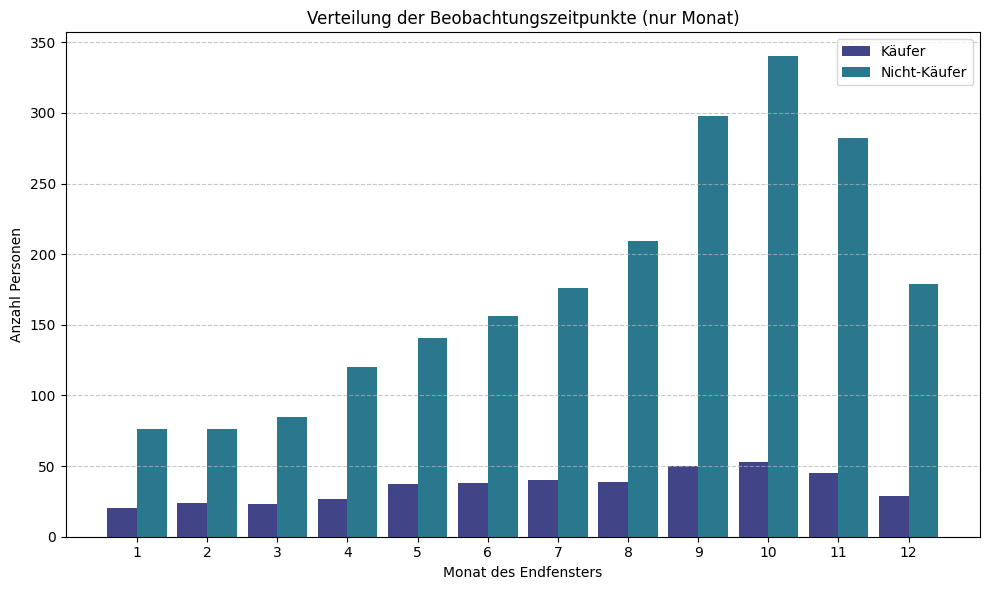

In [401]:
# Monatswerte aus end_window extrahieren
full_df['end_month'] = full_df['end_window'].dt.month

# Käufer- vs. Nicht-Käufer-Gruppen
buyers = full_df[full_df['has_credit_card'] == 1]['end_month']
non_buyers = full_df[full_df['has_credit_card'] == 0]['end_month']

# Plot
plt.figure(figsize=(10, 6))
plt.hist(
    [buyers, non_buyers],
    bins=np.arange(1, 14) - 0.5,  # 12 bins für Monate 1–12
    label=['Käufer', 'Nicht-Käufer'],
    color=plt.cm.viridis([0.2, 0.4]),
    rwidth=0.85
)

plt.xticks(range(1, 13))
plt.xlabel('Monat des Endfensters')
plt.ylabel('Anzahl Personen')
plt.title('Verteilung der Beobachtungszeitpunkte (nur Monat)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Für jede Person wurde ein 12-monatiges Beobachtungsfenster definiert, das als Basis für spätere Analysen dient. Dabei wurde zwischen Kreditkarten-Käufern und Nicht-Käufern differenziert:

Käufer:  

Das Beobachtungsfenster endet einen Monat vor dem Ausgabedatum der Kreditkarte (issued) und umfasst die vorhergehenden 12 Monate. So ist gewährleistet, dass nur verhaltensbezogene Daten vor der Kartenausstellung betrachtet werden.

Nicht-Käufer:  

Diese Personen besitzen keine Kreditkarte, erhalten aber ein Beobachtungsfenster zur Vergleichbarkeit. Für jede Person wurden alle möglichen 12-Monats-Zeiträume innerhalb ihrer Historie ermittelt, in denen sie lückenlos Daten hatten.  
Aus diesen gültigen Zeitfenstern wurde zufällig eines gezogen, wobei die Auswahl gewichtet erfolgte.  
Ziel war es, dass sich die Monatsverteilung der Endzeitpunkte (z. B. wie viele Fenster im Januar oder Juni enden) möglichst an die Verteilung der Käufer anlehnt.  
Damit entsteht eine realistische, aber vergleichbare Referenzgruppe mit ähnlicher saisonaler Struktur.

### *Übersicht der selber konstruierten Predictive Features*

Folgende Merkmalsgruppen wurden aus den Rohdaten abgeleitet und für das Modell verwendet:

**Demografische Merkmale**:  

Kundenalter (alter_1999), Geschlecht (gender), Bezirk-ID und zugehörige demografische Kennzahlen (Einwohnerzahl, avg_salary, urban_ratio, etc.). Diese festen Merkmale stammen aus CLIENT bzw. DISTRICT und beschreiben die Kundengrunddaten.

**Kontomerkmale**: Aus ACCOUNT und DISP:

•	frequency: Kontoauszug-Frequenz (z.B. monatlich).  
•	date_created: Eröffnungsdatum des Kontos (kann in Alter des Kontos umgerechnet werden).  
•	Daueraufträge: perm_order_count, perm_order_sum (Anzahl und Summe der regelmäßigen Zahlungsaufträge).  
•	Kredit: loan_status (Status bestehender Kredite auf diesem Konto).

**Transaktionsbasierte Aggregate** (Rollup-Fenster): Über den definierten 12-Monats-Zeitraum vor dem Kauf (bzw. Vergleichszeitpunkt) wurden folgende Kennzahlen berechnet:

•	amount_sum_total: Gesamtumsatz (Summe aller Transaktionsbeträge) im Fenster.  
•	amount_mean_monthly: Mittlerer Monatsumsatz (amount_sum_total / 12).  
•	trans_count_total: Gesamtzahl der Transaktionen im Fenster.  
•	trans_count_mean: Mittlere Transaktionszahl pro Monat.  

**Kontostandsstatistiken**: Aus den täglichen Saldenreihen:

•	balance_mean_avg: Durchschnitt der monatlichen Durchschnitts-Salden (Mittelwert über alle Monate).  
•	balance_mean_std: Standardabweichung der monatlichen Durchschnitts-Salden (Volatilität).  
•	balance_min_total: Kleinster Monatsend-Saldo im Fenster.  
•	balance_max_total: Größter Monatsend-Saldo im Fenster.  
•	balance_vola_avg: Durchschnitt der (Monats-Extreme-/Mittelsaldo) im Fenster.

**Spezielle Transaktionen**: Zähler für bestimmte Buchungen:

•	cash_withdrawal_count_total, cash_withdrawal_amount_total: Anzahl und Summe aller Bargeldabhebungen im Fenster.  
•	insurance_count_total: Anzahl Versicherungszahlungen.  
•	penalty_interest_count_total: Anzahl Strafzins-Buchungen. 

**Trend- und Änderungsmerkmale**: Sie erfassen Entwicklungen über die Zeit:

•	amount_trend_slope: Lineare Steigung der Monatsumsatz-Zeitreihe (positiv = wachsend).  
•	balance_trend_slope: Steigung des monatlichen Durchschnittssaldos.  
•	trans_trend_slope: Steigung der monatlichen Transaktionszahlen.  
•	amount_median_change: Differenz der Median-Umsätze der letzten 3 vs. ersten 3 Monate (zeigt Trendrichtungen).

Diese Features fassen zusammen, wie aktiv bzw. liquide ein Kunde war (Umsätze, Bargeldabhebungen), wie stabil sein Saldo war sowie seine Basisdaten (Alter, Wohnort etc.). Sie dienen als Prädiktoren für die Kreditkarten-Affinität.

### *Übersicht der gesamten zeitlichen Entwicklung von Vermögen und Umsatz für Konto Nummer 14 und Nummer 18 pro Monat*

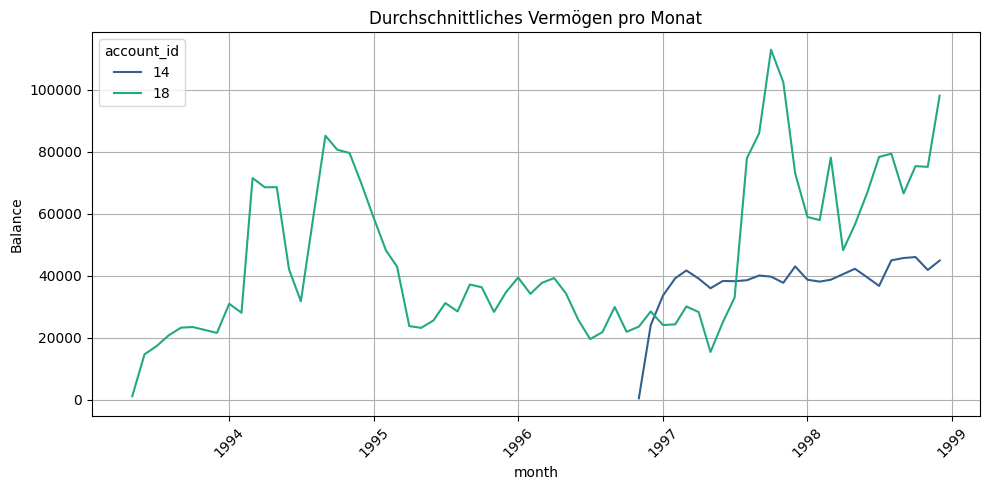

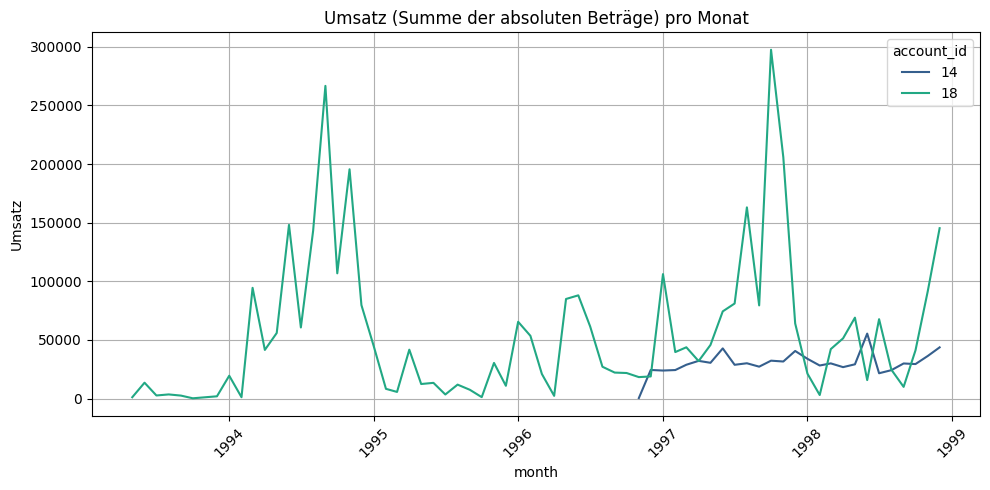

In [402]:
# Monat extrahieren und in datetime umwandeln
df_trans["month"] = df_trans["date"].dt.to_period("M").dt.to_timestamp()

# Filter auf Konto 14 und 18
df_filtered = df_trans[df_trans["account_id"].isin([14, 18])]

# Gruppieren und Aggregieren
monthly = df_filtered.groupby(["month", "account_id"]).agg(
    balance=("balance", "mean"),
    amount=("amount", lambda x: x.abs().sum())
).reset_index()

# Farben definieren
colors = plt.cm.viridis([0.3, 0.6]).tolist()

# Plot für Vermögen
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x="month", y="balance", hue="account_id", palette=colors)
plt.title("Durchschnittliches Vermögen pro Monat")
plt.ylabel("Balance")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# Plot für Umsatz
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x="month", y="amount", hue="account_id", palette=colors)
plt.title("Umsatz (Summe der absoluten Beträge) pro Monat")
plt.ylabel("Umsatz")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

Konto 14 wirkt wie ein typisches Privatkonto mit stabiler Finanzlage.  
Konto 18 ist deutlich aktiver, volatiler und weist Merkmale größerer finanzieller Operationen auf – evtl. ein Geschäftskonto oder spekulatives Verhalten.

## Feature Selection

### Mögliche Data Leakage Features

Definition Data Leakage:  
Wenn Informationen in den Trainingsdaten enthalten sind, die in der Realität zum Zeitpunkt der Vorhersage nicht bekannt wären, oder direkt aus der Zielvariable ableitbar sind.

Ein Feature ist dann problematisch, wenn es eine versteckte Abhängigkeit zum Ziel aufweist. Ein Merkmal "leakt", wenn es eng mit dem Ziel verknüpft ist, auch ohne direkten Zugriff auf das Label. Beispielsweise kann das Alter eines Kredits oder dessen Status nach Kauf mit der Kreditkartenausgabe korrelieren.  
Zudem wird empfohlen, sämtliche Preprocessing- und Selektionsschritte nur auf Trainingsdaten anzuwenden, um Train-Test-Contamination zu verhindern.

Einige Spalten im full_df enthalten direkt zielbezogene Informationen. Insbesondere sind dies:

•	issued (Karten-Ausgabedatum): Dies ist das tatsächliche Kaufdatum der Kreditkarte. Es ist eine Zukunftsinformation (wird erst nach Abschluss des Kaufs bekannt). Die Einbeziehung würde dem Modell quasi die Antwort geben.

•	card_type / card_id: Diese Merkmale sind nur für Kreditkartenbesitzer belegt (z.B. „Classic“ oder „Gold“). Ein Modell könnte daraus direkt ableiten, ob eine Karte existiert. Sie verbergen direkt das Label in anderen Worten.

•	Features aus dem Kreditkarten-Datensatz allgemein: Jede Information aus der Kreditkarte-Tabelle (außer dem Label has_credit_card) enthält Post-Kauf-Daten. Diese dürfen nicht als Prädiktoren verwendet werden.

•	Berechnung aus zukünftigen Transaktionen: Würde man z.B. Kundenaktivität nach dem Kaufdatum mit einbeziehen, gäbe man dem Modell wieder Zukunftsdaten. Unsere Aggregationen wurden bewusst so gewählt, dass nur Daten vor dem Endzeitpunkt (end_window) genutzt werden.

### Informationen zum 'loan' als Data Leak

Um Data Leakage vollständig auszuschliessen, müssen alle Loans, die nach der Kreditkartenvergabe, respektive nach dem End Window vergeben wurden aus der Modellbetrachtung ausgeschlossen werden. Wir setzten den loan_status dazu auf None.

In [403]:
# Anzahl loan_status 'None' before
before = full_df["loan_status"].value_counts()['None']
# Loan Status None für alle Einträge, die nach dem Endfenster liegen
full_df.loc[full_df["loan_date"] > full_df["end_window"], "loan_status"] = 'None'
# Kategorie sicherstellen
full_df["loan_status"] = full_df["loan_status"].astype("category")
# Anzahl loan_status 'None' after
after = full_df["loan_status"].value_counts()['None']
print(f"Anzahl loan_status 'None' vor: {before}, nach: {after}")

Anzahl loan_status 'None' vor: 2371, nach: 2429


### Informationen zu den Districten als Data Leak

Wenn man aus der district-Tabelle Merkmale nutzt, die nicht zum Vorhersagezeitpunkt verfügbar waren (z. B. spätere Arbeitslosenzahlen), kann das zu Leakage führen. Wir dürfen nur Features übernehmen, die zeitlich vor oder während des Trainingsfensters verfügbar sind.

Ein möglicher Ansatz wäre, anstelle der Merkmale einfach nur die distric_id als kategorische Variabel ( One-hot-encoded ) zu nutzen. Schliesslich kodiert er implizit dieselben Informationen wie die district-Tabelle. Allerdings leidet daran die Erklärbarkeit des Modells ( Man weiss nicht mehr, was genau das Modell an Bezirk 23 mag – nur dass es ihn bevorzugt. Einkommen? Urbanität? Einwohnerzahl? )

Um die Erklärbarkeit zu gewährleisten, Data Leakage auszuschliessen und das Modell zu vereinfachen wählen wir nur einige Merkmale aus:


| Feature                                   | Behalten? | Begründung                                                                 |
|-------------------------------------------|-----------|----------------------------------------------------------------------------|
| `district_id`, `district_name`             | ❌        | Nicht modellrelevant  |
| `region`                                  | ✅        | Interessant                                              |
| `no_inhabitants`                          | ✅        | Wichtig, stabil, nicht leaky                                               |
| `municipalities_*`                        | ❌        | Hoch korreliert mit `no_inhabitants`                                       |
| `no_cities`                               | ❌        | Korreliert stark mit Bevölkerung/Urbanität                                 |
| `urban_ratio`                             | ✅        | Gute verdichtete Information über Siedlungsstruktur                        |
| `avg_salary`                              | ✅        | Sehr nützlich, stabil und erklärbar                                        |
| `unemployment_1995`, `unemployment_1996`  | ❌        | Leakage-Risiko                                                              |
| `entrepreneurs_per_1000`                  | ❌        | Potenziell korreliert mit Einkommen, schwer interpretierbar                |
| `crimes_1995`, `crimes_1996`              | ❌        | Zeitlich riskant (potenzielles Leakage)                                   |


### Bereinigen unnötiger Informationen

In [404]:
# Anzahl eindeutiger Kombinationen aus disp_id, client_id und account_id
unique_combos = full_df[['disp_id', 'client_id', 'account_id']].drop_duplicates()

# Vergleich: Anzahl disp_id == Anzahl eindeutiger Kombinationen?
is_unique_mapping = len(unique_combos) == full_df['disp_id'].nunique()

print(f"Eindeutige Zuordnung von disp_id zu client_id/account_id: {is_unique_mapping}")

Eindeutige Zuordnung von disp_id zu client_id/account_id: True


In [405]:
# Gruppieren nach client_id und Anzahl unterschiedlicher Konten zählen
konto_pro_kunde = full_df.groupby('client_id')['account_id'].nunique()

# Kunden mit mehr als einem Konto
mehrfach_kunden = konto_pro_kunde[konto_pro_kunde > 1]

print(f"Anzahl Kunden mit mehr als einem Konto: {len(mehrfach_kunden)}")

Anzahl Kunden mit mehr als einem Konto: 0


Es ist keine weitere Aggretation nötig, um pro Zeile einen Kunden zu haben.

In [406]:
full_df.role.value_counts()

role
OWNER        2563
DISPONENT       0
Name: count, dtype: int64

'role' enthält keine Information für das Modell.

In [407]:
# Gefahr von Data Leakage, Redundanz oder haben keinen Informationswert
drop_cols = [
    # IDs & technische Felder
    'role', 'client_id', 'disp_id', 'account_id', 'card_id',
    'district_name', 'district_id',

    # Zeitlich riskante oder leaky Felder
    'birth_date', 'loan_date', 'issued',
    'unemployment_1995', 'unemployment_1996',
    'crimes_1995', 'crimes_1996',

    # Redundante oder stark korrelierte Felder
    'municipalities_under_500', 'municipalities_500_1999',
    'municipalities_2000_9999', 'municipalities_over_10000',
    'no_cities', 'entrepreneurs_per_1000', 'card_type',

    # Nichtmodellrelevante Zeitmerkmale
    'start_window', 'date_created'
]

# Entfernen irrelevanter Spalten
reduced_df = full_df.drop(columns=drop_cols)


In [408]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2563 entries, 0 to 2562
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   gender                        2563 non-null   category      
 1   alter_1999                    2563 non-null   Int64         
 2   frequency                     2563 non-null   category      
 3   region                        2563 non-null   category      
 4   no_inhabitants                2563 non-null   int64         
 5   urban_ratio                   2563 non-null   float64       
 6   avg_salary                    2563 non-null   int64         
 7   perm_order_count              2563 non-null   int64         
 8   perm_order_sum                2563 non-null   float64       
 9   loan_status                   2563 non-null   category      
 10  has_credit_card               2563 non-null   bool          
 11  months_history                

In [409]:
# Numerische Spalten (int, float, aber kein bool)
num_cols = reduced_df.select_dtypes(include=['int64', 'float64', 'Int64']).columns.tolist()

# Kategorische Spalten (category, object, bool)
cat_cols = reduced_df.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()
cat_cols.remove('has_credit_card')

# Ergebnis anzeigen
print("Numerische Spalten:", num_cols)
print("Kategorische Spalten:", cat_cols)

Numerische Spalten: ['alter_1999', 'no_inhabitants', 'urban_ratio', 'avg_salary', 'perm_order_count', 'perm_order_sum', 'months_history', 'amount_sum_total', 'amount_mean_monthly', 'trans_count_total', 'trans_count_mean', 'balance_mean_avg', 'balance_mean_std', 'balance_vola_avg', 'balance_min_total', 'balance_max_total', 'cash_withdrawal_count_total', 'cash_withdrawal_amount_total', 'insurance_count_total', 'penalty_interest_count_total', 'amount_trend_slope', 'balance_trend_slope', 'trans_trend_slope', 'amount_median_change']
Kategorische Spalten: ['gender', 'frequency', 'region', 'loan_status']


In [410]:
# check for missing values
missing = reduced_df.isnull().sum()
print(f'{len(missing[missing > 0])} columns with missing values')

0 columns with missing values


In [411]:
# check for duplicates
duplicates = reduced_df.duplicated().sum()
print(f'{duplicates} duplicates found')

0 duplicates found


Einige Spalten wurden aus dem finalen full_df entfernt, weil sie:  

•	❗ Data Leakage verursachen könnten.  
•	♻️ redundant sind.  
•	📉 keinen Informationswert für das Modell tragen.

### Explorative Datenanalyse

Um den Datensatz etwas besser zu verstehen suchen wir Zusammenhänge der verschiedenen Features zur Zielvariabel, also ob ein Kunde eine Kreditkarte besitzt oder nicht.

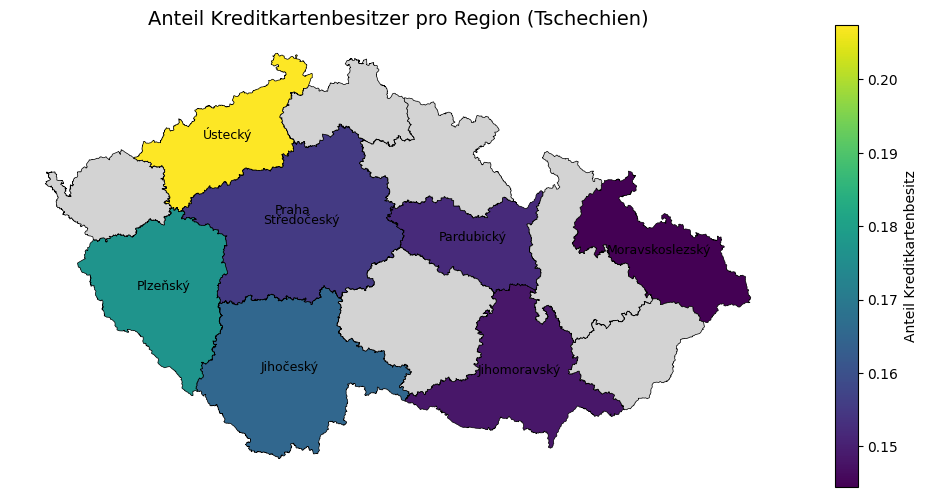

In [412]:
# Karte: Anteil Kreditkartenbesitz pro Region (Kraj)
import geopandas as gpd

# 1. GeoJSON laden (Pfad ggf. anpassen)
gdf_regions = gpd.read_file("geojson/kraje.json")

# 2. Mapping von deinen Regionen zu offiziellen Kraje
region_mapping = {
    "Prague": "Praha",
    "central Bohemia": "Středočeský",
    "west Bohemia": "Plzeňský",
    "north Bohemia": "Ústecký",
    "east Bohemia": "Pardubický",
    "south Bohemia": "Jihočeský",
    "south Moravia": "Jihomoravský",
    "north Moravia": "Moravskoslezský"
}

# ⚠️ Umwandeln in string und ersetzen, um FutureWarning zu vermeiden
reduced_df["region"] = reduced_df["region"].astype(str).replace(region_mapping)

# 3. Mapping von NUTS3-ID auf Regionennamen im GeoDataFrame
nuts_to_region = {
    "CZ0100000000": "Praha",
    "CZ0200000000": "Středočeský",
    "CZ0310000000": "Jihočeský",
    "CZ0320000000": "Plzeňský",
    "CZ0410000000": "Karlovarský",
    "CZ0420000000": "Ústecký",
    "CZ0510000000": "Liberecký",
    "CZ0520000000": "Královéhradecký",
    "CZ0530000000": "Pardubický",
    "CZ0630000000": "Vysočina",
    "CZ0640000000": "Jihomoravský",
    "CZ0710000000": "Olomoucký",
    "CZ0720000000": "Zlínský",
    "CZ0800000000": "Moravskoslezský"
}

gdf_regions["region"] = gdf_regions["id"].map(nuts_to_region)

# 4. Aggregation der Kreditkartenanteile
region_stats = reduced_df.groupby("region", observed=False).agg(
    total_customers=("has_credit_card", "count"),
    credit_card_share=("has_credit_card", "mean")
).reset_index()

# 5. Merge mit GeoDataFrame
gdf_merged = gdf_regions.merge(region_stats, on="region", how="left")

# 6. Plot erstellen
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Choroplethenkarte
gdf_merged.plot(column='credit_card_share', cmap='viridis', legend=True,
                legend_kwds={'label': "Anteil Kreditkartenbesitz", 'shrink': 0.6},
                missing_kwds={'color': 'lightgrey'},
                edgecolor='black', linewidth=0.5, ax=ax)

# Regionstitel setzen
plt.title("Anteil Kreditkartenbesitzer pro Region (Tschechien)", fontsize=14)

# Achsen ausblenden
plt.axis('off')

# Zentroiden berechnen (für Label-Position)
gdf_labeled = gdf_merged.dropna(subset=["credit_card_share"]).copy()
# Projektionssystem transformieren (z. B. EPSG:5514 für CZ)
gdf_labeled_proj = gdf_labeled.to_crs(epsg=5514)

# Zentroiden im metrischen System berechnen
gdf_labeled["coords"] = gdf_labeled_proj.centroid.to_crs(gdf_labeled.crs)

# Beschriftungen hinzufügen
for _, row in gdf_labeled.iterrows():
    plt.annotate(text=row["region"],
                 xy=(row["coords"].x, row["coords"].y),
                 horizontalalignment='center',
                 fontsize=9,
                 color='black')

plt.tight_layout()
plt.show()


Auf der Karte sehen wir mit hellen Farben (gelb/grün) → hoher Anteil an Kreditkartenbesitzern und mit dunkle Farben (blau/lila) → niedriger Anteil.  
Graue Regionen → keine Daten vorhanden.

Der hohe Anteil an Kreditkartenbesitzern in Ústecký (north Bohemia) könnte mehrere Ursachen haben. Möglicherweise ist die Region stärker urbanisiert oder beherbergt viele wirtschaftlich aktive Kunden mit mittlerem Einkommen, was Kreditwürdigkeit und Kartennutzung begünstigt. Auch gezielte Bankstrategien oder historische Faktoren – z. B. durch industrielle Prägung – könnten dazu geführt haben, dass dort mehr Konten und Kartenprodukte vertrieben wurden. Nicht zuletzt ist ein verzerrter Sample-Effekt möglich, falls in der Stichprobe überproportional viele kartennutzende Kundentypen aus dieser Region enthalten sind.

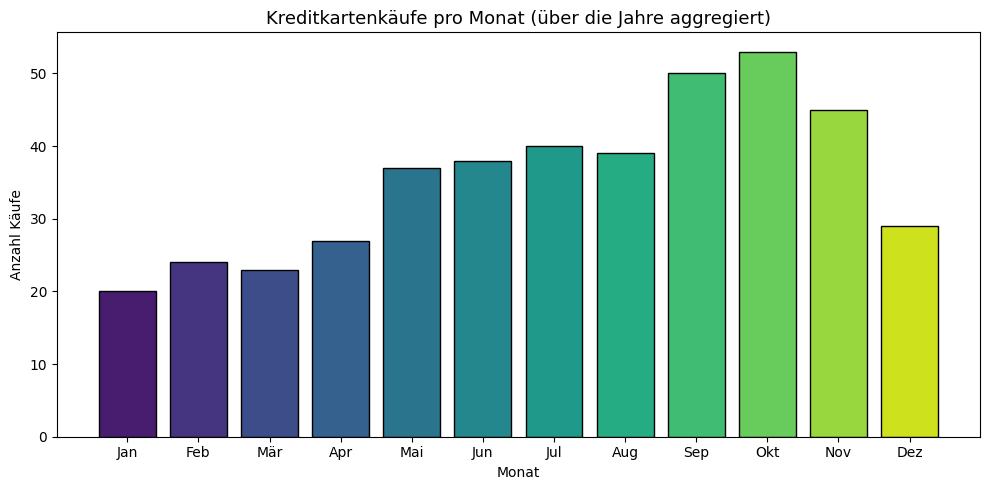

In [413]:
# Nur Kreditkartenkäufe
df_käufe = reduced_df[reduced_df['has_credit_card'] == True]
monthly_counts = df_käufe['end_month'].value_counts().sort_index()

# Farben vorbereiten (viridis)
colors = sns.color_palette("viridis", len(monthly_counts))

# Monatsnamen
month_labels = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun',
                'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']

# Plot mit Matplotlib direkt
plt.figure(figsize=(10, 5))
plt.bar(x=monthly_counts.index, height=monthly_counts.values,
        color=colors, edgecolor='black')

plt.xticks(ticks=range(1, 13), labels=month_labels)
plt.title('Kreditkartenkäufe pro Monat (über die Jahre aggregiert)', fontsize=13)
plt.xlabel('Monat')
plt.ylabel('Anzahl Käufe')
plt.tight_layout()
plt.show()

Die Grafik zeigt die monatliche Verteilung von Kreditkartenkäufen, aggregiert über alle Jahre. Auffällig ist ein klarer saisonaler Trend: Die Zahl der Käufe steigt kontinuierlich von Januar bis Oktober an, mit einem Höhepunkt im Oktober. Danach sinkt die Aktivität wieder deutlich, besonders im Dezember.

Dieses Muster deutet darauf hin, dass Kreditkarten verstärkt in der zweiten Jahreshälfte vergeben oder genutzt werden, möglicherweise im Zusammenhang mit Herbstaktionen, Urlaubsfinanzierungen oder gezieltem Marketing vor dem Jahresende. Der Rückgang im Dezember könnte durch Feiertage, Budgetstopps oder eingeschränkte Bankprozesse bedingt sein.

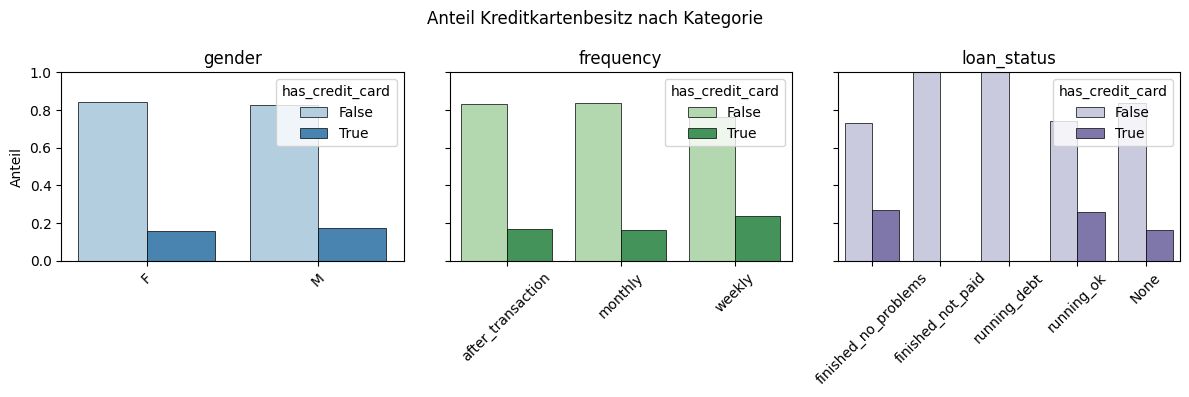

In [414]:
cat_vars = ['gender', 'frequency', 'loan_status']
colors = ['Blues', 'Greens', 'Purples'] 
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i, var in enumerate(cat_vars):
    ax = axes[i]
    
    # Anteil Kreditkartenbesitz je Kategorieausprägung
    prop_df = (
        reduced_df.groupby(var, observed=False)['has_credit_card']
        .value_counts(normalize=True)
        .rename('proportion')
        .reset_index()
    )
    
    # Balkenplot
    sns.barplot(data=prop_df, x=var, y='proportion', hue='has_credit_card',
                palette=sns.color_palette(colors[i], 2), edgecolor="black",
                linewidth=0.5, ax=ax)
    
    ax.set_title(f"{var}", fontsize=12)
    ax.set_ylabel("Anteil" if i == 0 else "")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

# Gesamttitel & Layout
plt.suptitle("Anteil Kreditkartenbesitz nach Kategorie")
plt.tight_layout()
plt.legend(title="has_credit_card")
plt.show()

Die Grafik zeigt den Anteil von Kreditkartenbesitzern innerhalb der Ausprägungen dreier kategorialer Merkmale: Geschlecht (gender), Transaktionsfrequenz (frequency) und Kreditstatus (loan_status).

Beim Geschlecht fällt auf, dass Frauen und Männer nahezu identische Kreditkartenquoten aufweisen – das Geschlecht hat also keinen wesentlichen Einfluss auf den Besitz einer Kreditkarte. Bei der Transaktionsfrequenz zeigt sich ein interessanter Effekt: Kunden mit wöchentlicher Transaktionsfrequenz besitzen deutlich häufiger eine Kreditkarte als jene mit monatlicher oder transaktionsbasierter Abwicklung. Das könnte auf eine aktivere Nutzung oder automatisierte Zahlungen hinweisen.

Beim Kreditstatus besitzen Kunden mit laufendem oder abgeschlossenem Kredit („running_ok“ oder „finished_no_problems“) deutlich häufiger Kreditkarten als jene mit Zahlungsproblemen („finished_not_paid“). Dies spricht dafür, dass ein stabiler Kreditstatus positiv mit der Kreditkartenvergabe zusammenhängt – vermutlich über Bonitätsbewertungen.

Insgesamt zeigt der Plot, dass Nutzungsverhalten und Zahlungszuverlässigkeit stärkere Prädiktoren für den Kreditkartenbesitz sind als demografische Merkmale wie das Geschlecht.

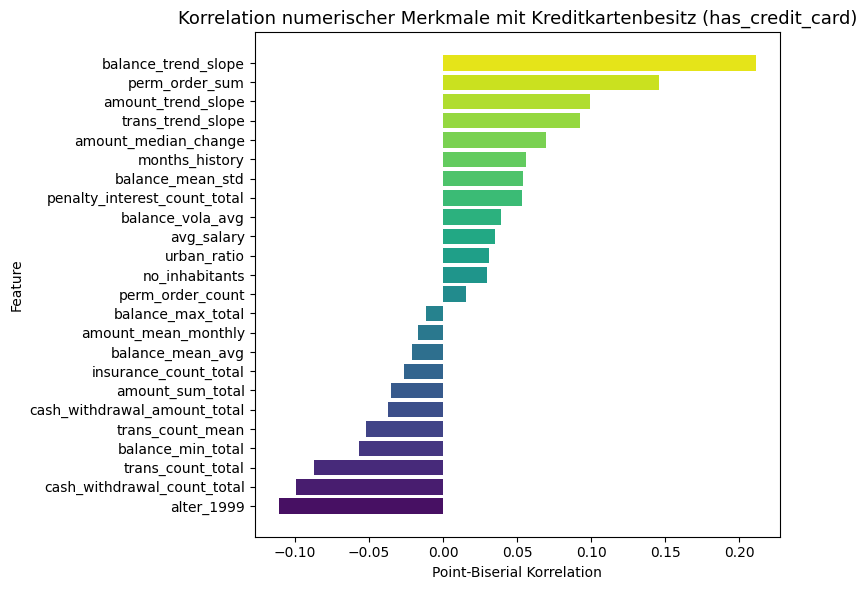

In [415]:
# Korrelationen numerischer Features mit has_credit_card (falls binär als int)
from scipy.stats import pointbiserialr

# 1. Korrelationen berechnen
corrs = []
for col in num_cols:
    try:
        corr, _ = pointbiserialr(reduced_df['has_credit_card'].astype(int), reduced_df[col])
        corrs.append((col, corr))
    except Exception as e:
        print(f"Fehler bei Spalte {col}: {e}")

# 2. Sortieren nach absoluter Stärke der Korrelation
corrs = sorted(corrs, key=lambda x: abs(x[1]), reverse=True)
corr_df = pd.DataFrame(corrs, columns=['Feature', 'Point-Biserial Corr'])

# 3. Plot
# Vorbereitung
corr_df_sorted = corr_df.sort_values('Point-Biserial Corr')
colors = sns.color_palette("viridis", len(corr_df_sorted))

# Plot manuell
plt.figure(figsize=(8, 6))
bars = plt.barh(y=corr_df_sorted['Feature'], width=corr_df_sorted['Point-Biserial Corr'], color=colors)

plt.title('Korrelation numerischer Merkmale mit Kreditkartenbesitz (has_credit_card)', fontsize=13)
plt.xlabel('Point-Biserial Korrelation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Die Point-Biserial Korrelation misst den linearen Zusammenhang zwischen einer binären und einer numerischen Variable.  
Konkret: Wie stark unterscheidet sich der Mittelwert der numerischen Variable zwischen den beiden Gruppen der binären Variable?   
Sie zeigt, wie gut ein numerisches Feature zwischen zwei Gruppen unterscheiden kann.

Der Barplot zeigt die Stärke des linearen Zusammenhangs zwischen einzelnen numerischen Merkmalen und der Zielvariable has_credit_card. Die Merkmale sind nach der absoluten Korrelation sortiert. Einige Features weisen dabei moderate Korrelationen zur Zielvariable auf – insbesondere perm_order_sum, penalty_interest_count_total, balance_trend_slope und amount_trend_slope. Diese Merkmale scheinen also einen relevanten Einfluss darauf zu haben, ob eine Person eine Kreditkarte besitzt oder nicht.

Ein positiver Korrelationswert – wie bei perm_order_sum – bedeutet, dass höhere Werte des Merkmals mit höherer Wahrscheinlichkeit auf Kreditkartenbesitz hinweisen. Negative Werte – wie bei cash_withdrawal_amount_total – deuten darauf hin, dass Personen ohne Kreditkarte tendenziell häufiger Bargeld abheben.

Insgesamt zeigt der Plot, dass es zwar keine einzelnen Features mit sehr starker Korrelation gibt, jedoch mehrere mit relevanten Mustern, die ein Modell zur Klassifikation nutzen kann. Das unterstreicht die Wichtigkeit einer Kombination vieler schwach bis moderat prädiktiver Merkmale.

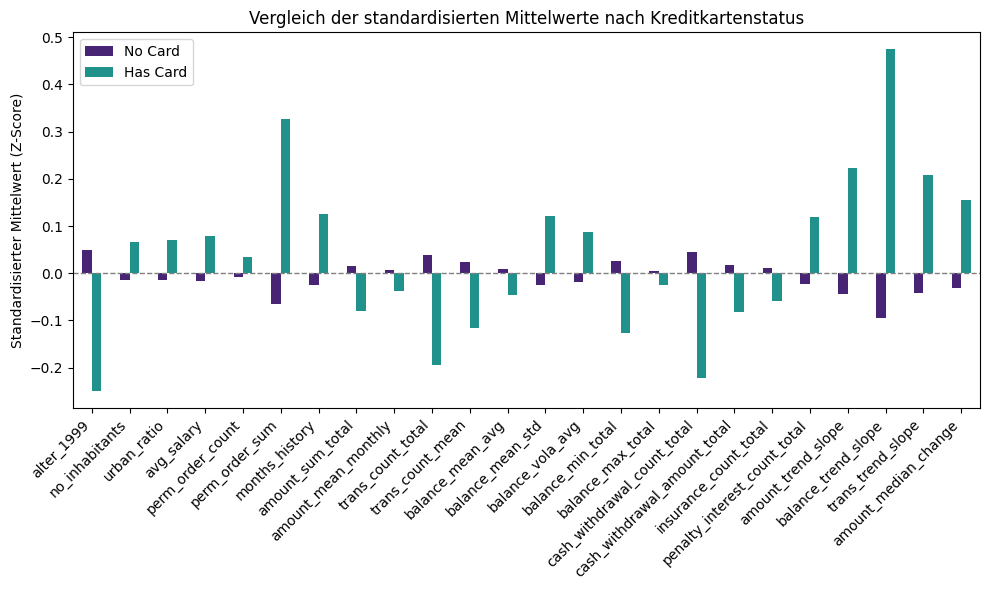

In [416]:
from sklearn.preprocessing import StandardScaler

# Werte standardisieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(reduced_df[num_cols])
df_scaled = pd.DataFrame(X_scaled, columns=num_cols)
df_scaled["has_credit_card"] = reduced_df["has_credit_card"].values

# Gruppierte Mittelwerte der standardisierten Features
means = df_scaled.groupby("has_credit_card")[num_cols].mean().T
means.columns = ['No Card', 'Has Card']

# Plot
means.plot(kind='bar', figsize=(10, 6), color=plt.cm.viridis([0.1, 0.5]))
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.ylabel("Standardisierter Mittelwert (Z-Score)")
plt.title("Vergleich der standardisierten Mittelwerte nach Kreditkartenstatus")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Interpretation von Z-Scores:

•	Werte > 0 → Merkmal liegt über dem Gesamtdurchschnitt  
•	Werte < 0 → Merkmal liegt unter dem Gesamtdurchschnitt  
•	Der Unterschied zwischen „Has Card“ und „No Card“ pro Feature zeigt, wie stark das Merkmal die Zielvariable trennt.

Der Plot zeigt die standardisierten Mittelwerte (Z-Scores) verschiedener numerischer Merkmale, getrennt nach Kreditkartenbesitz. Dabei lassen sich klare Unterschiede zwischen den Gruppen erkennen. Kunden mit Kreditkarte weisen im Durchschnitt höhere Werte bei Merkmalen wie perm_order_sum, penalty_interest_count_total, amount_trend_slope und balance_trend_slope auf. Diese Merkmale deuten auf ein aktiveres, dynamischeres Finanzverhalten hin, z. B. steigende Kontostände, regelmäßige Zahlungen oder auch Mahngebühren.

Gleichzeitig liegen Kreditkartenbesitzer bei Merkmalen wie cash_withdrawal_amount_total und balance_mean_avg unter dem Durchschnitt, was darauf hindeuten könnte, dass sie weniger Bargeld beziehen und ihre durchschnittlichen Kontostände tendenziell geringer sind. Besonders auffällig ist, dass der Wert für alter_1999 bei Kreditkartenbesitzern deutlich niedriger ist – das bedeutet, dass diese im Jahr 1999 im Schnitt jünger waren als Nichtbesitzer, was auf eine gezielte Ansprache jüngerer, wirtschaftlich aktiver Kunden schließen lässt.

Insgesamt zeigt die Grafik, dass sich Kreditkartenbesitzer nicht nur im Alter, sondern vor allem im finanziellen Verhalten und in der Kontodynamik signifikant von Nichtbesitzern unterscheiden.

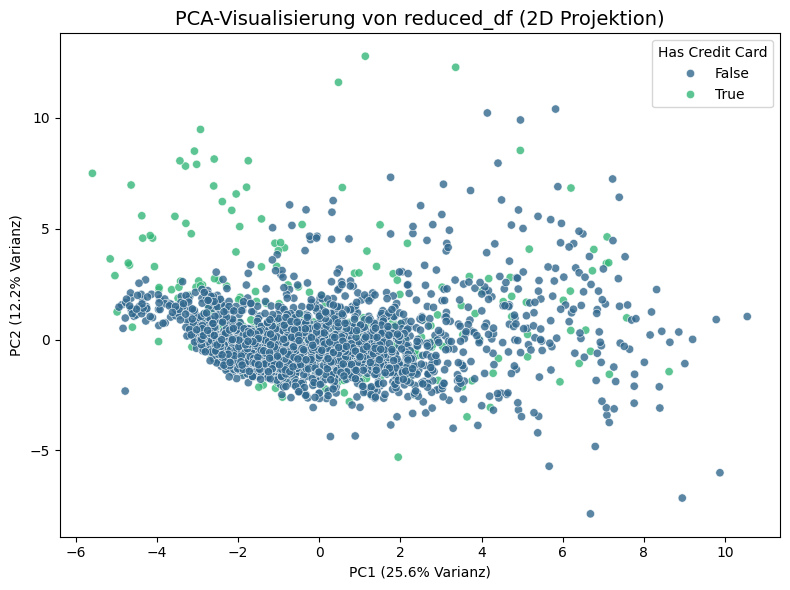

In [417]:
# PCA zur Visualisierung
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Ziel und numerische Features
features = reduced_df[num_cols]
y = reduced_df['has_credit_card']

# 2. Standardisierung
X_scaled = StandardScaler().fit_transform(features)

# 3. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. DataFrame für Plot
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['has_credit_card'] = y.values

# 5. Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='has_credit_card',
                palette='viridis', alpha=0.8)
plt.title('PCA-Visualisierung von reduced_df (2D Projektion)', fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Varianz)")
plt.legend(title='Has Credit Card', loc='best')
plt.tight_layout()
plt.show()

Der PCA-Plot zeigt eine zweidimensionale Projektion aller numerischen Merkmale, wobei jeder Punkt einem Kunden entspricht. Die Farben markieren, ob ein Kunde eine Kreditkarte besitzt oder nicht.

Obwohl die beiden Gruppen (mit und ohne Kreditkarte) überlappen, lassen sich leichte Unterschiede in der Verteilung erkennen: Kreditkartenbesitzer (grün) tendieren dazu, sich etwas stärker in bestimmten Randbereichen zu sammeln – insbesondere in Regionen mit höherem PC1-Wert. Das deutet darauf hin, dass sich Kreditkartenbesitzer in bestimmten Merkmalen systematisch von Nichtbesitzern unterscheiden. Die erste Hauptkomponente (PC1) erklärt rund 26 % der Gesamtvarianz und scheint also bereits relevante Trennungspotenziale zu enthalten, während PC2 etwa 12 % beiträgt.

Insgesamt zeigt die Visualisierung, dass die Zielvariable nicht klar linear trennbar ist, aber dass es durchaus strukturelle Unterschiede gibt, die ein Klassifikationsmodell nutzen kann. Ein nichtlinearer Ansatz wie ein Entscheidungsbaum oder ein Ensemblemodell könnte von diesen feinen Verteilungen profitieren.

## Modellentwicklung

### *Visualisierung und Beschreibung der Strategie zur Aufteilung der Daten*

Bei der Modellierung berücksichtigen wir explizit die zeitliche Struktur der Daten, um ein realistisches und robustes Bewertungsszenario zu schaffen. Die Zielvariable `has_credit_card` soll auf Basis historischer Kundeninformationen vorhergesagt werden – daher ist es entscheidend, dass keine zukünftigen Informationen unabsichtlich in das Modelltraining einfließen.

Warum eine zeitbasierte Aufteilung?

Würden wir Trainings- und Validierungsdaten zufällig aufteilen, könnten Informationen aus der "Zukunft" (aus Sicht des Trainingszeitpunkts) in das Modell gelangen. Dies würde zu Data Leakage führen – das Modell hätte Zugriff auf Daten, die in der Praxis zum Vorhersagezeitpunkt noch gar nicht bekannt sind. Die Folge wäre eine unrealistisch hohe Modellgüte im Validierungsprozess, die sich im realen Einsatz nicht reproduzieren lässt.

Um dies zu vermeiden, nutzen wir eine **zeitlich geordnete Aufteilung** der Daten. Die chronologische Trennung stellt sicher, dass das Modell nur auf Vergangenes trainiert wird und auf Zukünftiges validiert bzw. getestet wird.

Die Daten werden in drei zeitlich getrennte Sets aufgeteilt:

- **Trainingsdaten (`train_set`)**: enthalten nur Daten aus einem früheren Zeitraum (z. B. bis Ende 1997). Diese werden zur Modellanpassung verwendet.
- **Validierungsdaten (`val_set`)**: umfassen einen darauffolgenden Zeitraum (z. B. das Jahr 1998) und dienen der Hyperparameter-Optimierung mittels zeitbasierter Cross-Validation.
- **Testdaten (`test_set`)**: stammen aus dem letzten Zeitraum (z. B. 1999) und bleiben während des gesamten Modelltrainings unberührt. Sie dienen ausschließlich der finalen Evaluation des besten Modells unter realitätsnahen Bedingungen.

Zeitbasierte Cross-Validation mit `TimeSeriesSplit`

Für das Hyperparameter-Tuning innerhalb des Trainings- und Validierungszeitraums verwenden wir `TimeSeriesSplit` aus `scikit-learn`. Dabei wird in mehreren Schritten jeweils auf einem wachsenden Zeitfenster trainiert und auf dem nächsten Zeitabschnitt validiert. Dies respektiert die zeitliche Ordnung der Daten und vermeidet auch innerhalb der Grid Search jegliches Data Leakage.


<img src="img/data_partitioning.png" alt="Visualisierung" width="800"/>

In [418]:
# Nach Datum sortieren
reduced_df = reduced_df.sort_values("end_window").reset_index(drop=True)

# Aufteilen: erste 80% → Training, letzte 20% → Test
split_index = int(len(reduced_df) * 0.8)
train_set = reduced_df.iloc[:split_index].copy()
test_set = reduced_df.iloc[split_index:].copy()

# Ausgabe zur Kontrolle
print("Trainingsdaten:  ", train_set["end_window"].min().date(), "–", train_set["end_window"].max().date(), f"({len(train_set)} Zeilen)")
print("Testdaten:       ", test_set["end_window"].min().date(), "–", test_set["end_window"].max().date(), f"({len(test_set)} Zeilen)")

Trainingsdaten:   1993-12-31 – 1998-09-30 (2050 Zeilen)
Testdaten:        1998-09-30 – 1998-12-31 (513 Zeilen)


Das Test-Set repräsentiert echte, zukünftige Daten, die das Modell in der Praxis vorhersagen soll.

Verwendet man das Test-Set bereits für die Auswahl oder das Feintuning von Modellen – etwa beim Vergleich verschiedener Modellvarianten, Hyperparameter oder Feature-Kombinationen – besteht die Gefahr, dass das finale Modell (bewusst oder unbewusst) auf die speziellen Eigenschaften des Test-Sets abgestimmt wird. Dies führt zu einer verzerrten Schätzung der Modellgüte (sogenanntes „Data Leakage“ oder „Test Set Leakage“). Der auf diese Weise erzielte Testwert ist dann zu optimistisch und nicht mehr aussagekräftig für die tatsächliche Modellqualität auf völlig neuen, ungesehenen Daten.

Stattdessen werden alle Schritte der Modellentwicklung (Training, Cross-Validation, Modellauswahl, Feature Engineering etc.) ausschließlich auf dem Trainings-Set ( unter Einsatz von Cross-Validation ) durchgeführt. Das Test-Set kommt erst ganz am Ende ins Spiel – wenn das finale, vollständig gewählte Modell feststeht. Nur so erhält man eine wirklich objektive und ehrliche Einschätzung der Modellleistung.

### Baseline Modell mit logistischer Regression

Mit den Informationen alter1999, gender, region, balance_mean_avg und amount_sum_total erstellen wir ein Baseline Modell mit Logistischer Regression.

In [419]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# --- Feature-Auswahl ---
features = ['alter_1999', 'gender', 'region', 'balance_mean_avg', 'amount_sum_total']
target = 'has_credit_card'

X_train = train_set[features]
y_train = train_set[target]

# --- Preprocessing: Numerisch und Kategorisch trennen ---
numeric_features = ['alter_1999', 'balance_mean_avg', 'amount_sum_total']
categorical_features = ['gender', 'region']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# --- Pipeline ---
pipe = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'))
])

# --- GridSearchCV mit TimeSeriesSplit ---
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'clf__C': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best ROC AUC (CV):", grid.best_score_)
print("Best Parameters:", grid.best_params_)

Best ROC AUC (CV): 0.5694254090375077
Best Parameters: {'clf__C': 0.05}


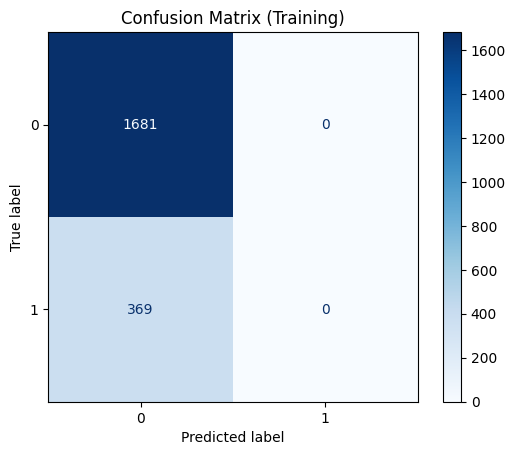

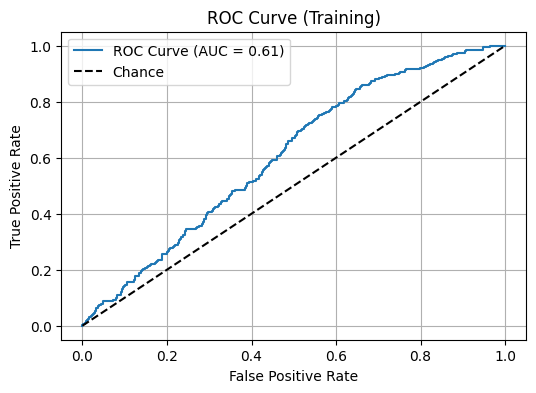

In [420]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

def plot_confusion_and_roc(model, X, y, title_suffix="Set"):
    """
    Plottet Confusion Matrix und ROC Curve für gegebene Daten & Modell.
    
    Args:
        model: trainiertes Modell (muss predict & predict_proba können)
        X: Features (DataFrame oder Array)
        y: True Labels (Series oder Array)
        title_suffix: 'Training', 'Test', etc.
    """
    # Vorhersagen & Wahrscheinlichkeiten
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix ({title_suffix})')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve ({title_suffix})')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_confusion_and_roc(grid, X_train, y_train, title_suffix="Training")

Die Auswertung unseres Baseline-Modells mit logistischer Regression zeigt, dass die gewählten Merkmale derzeit nur eine sehr geringe Aussagekraft hinsichtlich der Zielvariable has_credit_card besitzen.

Klassenunbalance

Ein Blick auf die Zielvariable macht deutlich, dass die Daten stark unausgewogen sind:
	•	Nur 16.6 % der Kunden besitzen eine Kreditkarte (Käufer),
	•	83.4 % besitzen keine Kreditkarte (Nicht-Käufer).

Dieses Ungleichgewicht hat einen erheblichen Einfluss auf die Modellergebnisse:
Modelle, die keine spezifischen Maßnahmen gegen Klassenunbalance verwenden, neigen dazu, immer die Mehrheitsklasse zu prognostizieren. Das sehen wir auch an der Confusion Matrix: Das Modell sagt ausschließlich „Nicht-Käufer“ voraus und ignoriert komplett die Minderheitsklasse. Dadurch erscheinen herkömmliche Genauigkeitsmaße (Accuracy) künstlich hoch, obwohl die Fähigkeit zur Erkennung von Kreditkartenbesitzern praktisch nicht vorhanden ist.

Modellgüte

Die ROC-Kurve und der zugehörige AUC-Wert von 0.569 liegen nur knapp über dem Zufallsniveau. Das unterstreicht, dass das Modell kaum sinnvolle Muster zur Unterscheidung zwischen Käufern und Nicht-Käufern erkennt – weder aus den gewählten Merkmalen noch trotz Regularisierung.

### SMOTE zur Verbesserung der Modellergebnisse

Um diesem Problem zu begegnen, ist es sinnvoll, die Minderheitsklasse künstlich zu verstärken und damit die Klassifikationsbasis für das Modell zu verbessern. Ein gängiges Verfahren dafür ist SMOTE (Synthetic Minority Over-sampling Technique). SMOTE generiert neue, synthetische Beispiele der Minderheitsklasse, sodass das Modell nicht nur „lernt“, die Mehrheitsklasse vorherzusagen, sondern auch Muster für die seltenen Kreditkartenbesitzer erkennt.

In [421]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

rng = np.random.RandomState(42)

# --- Imbalanced Pipeline ---
pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('sampling', SMOTE(random_state=rng)),
    ('cls', LogisticRegression(random_state=rng, max_iter=1000, solver='lbfgs'))
])

param_grid = {
    "cls__class_weight": ["balanced", None, {1: 10, 0: 1}],
    "cls__C": [0.01, 0.05, 0.1],
    "sampling__k_neighbors": [5, 7, 9],
}

grid = GridSearchCV(
    pipeline,
    param_grid=[param_grid],
    cv=tscv,         
    scoring="roc_auc",
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best ROC AUC (CV):", grid.best_score_)
print("Best Parameters:", grid.best_params_)

Best ROC AUC (CV): 0.572118346752149
Best Parameters: {'cls__C': 0.01, 'cls__class_weight': 'balanced', 'sampling__k_neighbors': 5}


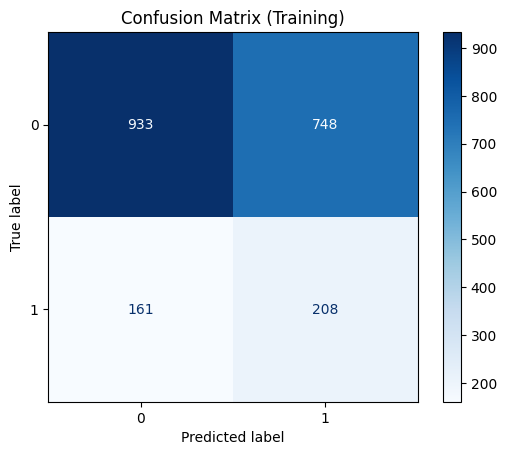

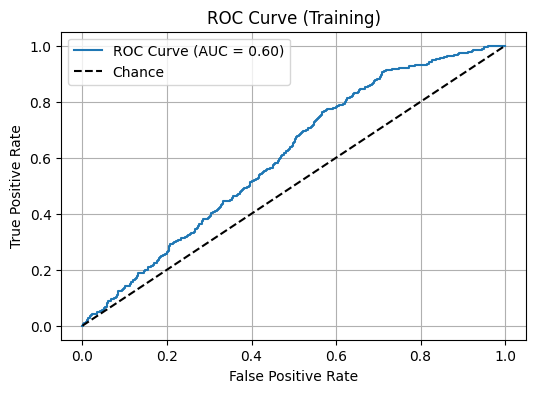

In [422]:
plot_confusion_and_roc(grid, X_train, y_train, title_suffix="Training")

Die Ergebnisse nach Anwendung von SMOTE zeigen, dass sich das Verhalten des Modells im Vergleich zur ursprünglichen Baseline verändert hat:

Confusion Matrix:

Das Modell erkennt nun beide Klassen – sowohl Kreditkartenbesitzer als auch Nicht-Besitzer – und sagt nicht mehr nur die Mehrheitsklasse voraus. Im Training werden von 354 tatsächlichen Kreditkartenbesitzern immerhin 208 korrekt erkannt (True Positives), 161 werden jedoch weiterhin übersehen (False Negatives). Bei den Nicht-Besitzern werden 933 korrekt als solche erkannt (True Negatives), jedoch werden 748 fälschlicherweise als Kreditkartenbesitzer klassifiziert (False Positives).
Dies zeigt, dass durch das Oversampling die Sensitivität (Recall) für die Minderheitsklasse gestiegen ist, allerdings auf Kosten einer höheren Fehlerrate bei der Mehrheitsklasse.

ROC Curve und AUC:

Die ROC-Kurve ergibt einen AUC-Wert von 0.572. Das ist zwar eine leichte Verbesserung gegenüber der Baseline (ohne SMOTE), aber immer noch nur knapp über dem Zufallsniveau. Das Modell kann die beiden Klassen also nach wie vor nur sehr eingeschränkt trennen. Die ROC-Kurve bleibt deutlich unter dem Idealverlauf.

Durch SMOTE gelingt es, das Modell „zu zwingen“, auch die Minderheitsklasse zu berücksichtigen. Die Trade-offs werden aber sichtbar: Mehr Kreditkartenbesitzer werden gefunden, dafür nimmt die Zahl der falsch-positiven Vorhersagen (fälschlich als Kreditkartenbesitzer klassifizierte Nicht-Kunden) stark zu. Insgesamt bleibt die Modellgüte weiterhin begrenzt, was darauf hindeutet, dass entweder die untersuchten Merkmale nicht ausreichend informativ sind, oder dass noch weiteres Feature Engineering notwendig ist.